# 03 - Training

**Thesis**: Multimodal Explainable AI for Breast Histopathology Classification  
**Experiment**: Train ConvNeXt-Base and Swin-Base on 3 stain normalization variants

---

This notebook covers:
1. **Training setup** - Loss function, optimizer, scheduler
2. **Ablation study** - 6 training runs (2 models x 3 stain methods)
3. **Learning curves** - Visualize training dynamics
4. **Results comparison** - Which model + stain method works best?

In [15]:
import os
import sys
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

import torch
import torch.nn as nn
from torch.optim.lr_scheduler import CosineAnnealingLR

sys.path.insert(0, os.path.abspath("."))
from src.config import *
from src.models import get_model, get_parameter_groups, count_parameters
from src.dataset import create_dataloaders
from src.trainer import Trainer, create_criterion, train_swin_progressive

# Reproducibility
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

print(f"Device: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

Device: cuda
GPU: AMD Radeon RX 6800 XT


## 1. Training Setup

### The Ablation Study Design

We train **6 models** total:

| Run | Model | Stain Method | Experiment Name |
|-----|-------|-------------|-----------------|
| 1 | ConvNeXt-Base | None (baseline) | `convnext_none` |
| 2 | ConvNeXt-Base | Macenko | `convnext_macenko` |
| 3 | ConvNeXt-Base | Reinhard | `convnext_reinhard` |
| 4 | Swin-Base | None (baseline) | `swin_none` |
| 5 | Swin-Base | Macenko | `swin_macenko` |
| 6 | Swin-Base | Reinhard | `swin_reinhard` |

**Why this design?** By keeping everything else constant (same split, same augmentation, same hyperparameters) and only varying the model and stain method, we can isolate:
1. **Model effect**: ConvNeXt vs Swin (averaging across stain methods)
2. **Stain effect**: None vs Macenko vs Reinhard (averaging across models)
3. **Interaction**: Does stain normalization help one model more than the other?

### Hyperparameters

| Parameter | Value | Why |
|---|---|---|
| Optimizer | AdamW | Standard for transformers, works well for CNNs too |
| Backbone LR | 1e-5 | Gentle fine-tuning of pretrained features |
| Head LR | 1e-3 | Fast learning for randomly-initialized classifier |
| Weight decay | 1e-4 | L2 regularization to prevent overfitting |
| Scheduler | Cosine Annealing | Smoothly decreases LR, proven to improve convergence |
| Batch size | 16 | Safe for 16GB VRAM with both models |
| Label smoothing | 0.1 | Prevents overconfidence |
| Early stopping | 15 epochs | Stops when validation F1 plateaus |
| Max epochs | 100 | Upper bound (early stopping usually triggers earlier) |

In [16]:
# 1.1 Define the training function for a single experiment

def run_experiment(model_name, stain_method, max_epochs=MAX_EPOCHS, batch_size=16):
    """
    Run a single training experiment.

    For Swin, uses 3-stage progressive unfreezing with layer-wise LR decay
    (see src/trainer.py:train_swin_progressive). ConvNeXt uses the standard
    discriminative-LR loop. The dispatch happens on model_name.

    Args:
        model_name: "convnext" or "swin"
        stain_method: "none", "macenko", or "reinhard"
        max_epochs: Maximum training epochs (ConvNeXt only; Swin uses phase_epochs)
        batch_size: Training batch size

    Returns:
        history dict and best validation F1
    """
    experiment_name = f"{model_name}_{stain_method}"

    # Check if already trained
    checkpoint_path = os.path.join(WEIGHTS_DIR, experiment_name, "best_model.pth")
    if os.path.exists(checkpoint_path):
        print(f"\n[{experiment_name}] Already trained. Loading results...")
        results_path = os.path.join(RESULTS_DIR, experiment_name, "training_history.csv")
        if os.path.exists(results_path):
            df = pd.read_csv(results_path)
            history = {col: df[col].tolist() for col in df.columns}
            best_f1 = max(history["val_f1"])
            print(f"  Best val F1: {best_f1:.4f}")
            return history, best_f1

    print(f"\n{'='*60}")
    print(f"Starting experiment: {experiment_name}")
    print(f"{'='*60}")

    # 1. Create DataLoaders
    train_dir = os.path.join(PROCESSED_DATA_DIR, stain_method, "train")
    val_dir = os.path.join(PROCESSED_DATA_DIR, stain_method, "val")
    test_dir = os.path.join(PROCESSED_DATA_DIR, stain_method, "test")

    train_loader, val_loader, _, class_weights = create_dataloaders(
        train_dir, val_dir, test_dir, batch_size=batch_size, num_workers=NUM_WORKERS
    )

    # 2. Create model
    model = get_model(model_name, num_classes=NUM_CLASSES, pretrained=True)
    total_params, _ = count_parameters(model)
    print(f"  Model: {model_name} ({total_params:,} params)")

    # 3. Create loss function (shared by both training paths)
    criterion = create_criterion(class_weights, label_smoothing=LABEL_SMOOTHING)

    if model_name == "swin":
        # ----- Swin: 3-stage progressive unfreeze + layer-wise LR decay -----
        history, best_f1 = train_swin_progressive(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            experiment_name=experiment_name,
            device=DEVICE,
            weight_decay=WEIGHT_DECAY,
            patience=EARLY_STOPPING_PATIENCE,
            phase_epochs=(20, 40, 40),
            phase_lrs=(1e-4, 3e-5, 1e-5),
            layerwise_decay=0.7,
        )
    else:
        # ----- ConvNeXt: discriminative LR fine-tune (unchanged) -----
        param_groups = get_parameter_groups(model, backbone_lr=1e-5, head_lr=1e-3)
        optimizer = torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)
        scheduler = CosineAnnealingLR(optimizer, T_max=max_epochs, eta_min=1e-7)

        trainer = Trainer(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            optimizer=optimizer,
            criterion=criterion,
            scheduler=scheduler,
            device=DEVICE,
            experiment_name=experiment_name,
            patience=EARLY_STOPPING_PATIENCE,
        )

        history = trainer.fit(max_epochs=max_epochs)
        best_f1 = max(history["val_f1"])

        del optimizer, trainer

    # Cleanup GPU memory
    del model, criterion
    torch.cuda.empty_cache()

    return history, best_f1

print("Training function ready.")

Training function ready.


## 2. Run All Experiments

This cell runs all 6 experiments sequentially. On your RX 6800 XT, expect roughly:
- **~15-30 min per experiment** (depending on early stopping)
- **~1.5-3 hours total** for all 6 runs

Each experiment saves checkpoints and results automatically, so if interrupted you can re-run and it will skip completed experiments.

In [20]:
# 2.1 Run all 6 experiments
MODEL_NAMES = ["convnext", "swin"]
all_results = {}

total_start = time.time()

for model_name in MODEL_NAMES:
    for stain_method in STAIN_METHODS:
        experiment_name = f"{model_name}_{stain_method}"
        history, best_f1 = run_experiment(model_name, stain_method, batch_size=16)
        all_results[experiment_name] = {
            "history": history,
            "best_f1": best_f1,
        }

total_time = time.time() - total_start
print(f"\n{'='*60}")
print(f"All experiments complete! Total time: {total_time/60:.1f} minutes")
print(f"{'='*60}")

# Summary table
print(f"\n{'Experiment':<25} {'Best Val F1':>12} {'Best Epoch':>12} {'Total Epochs':>14}")
print("-" * 65)
for name, result in all_results.items():
    h = result["history"]
    best_idx = int(np.argmax(h["val_f1"]))
    print(f"{name:<25} {result['best_f1']:>12.4f} {h['epoch'][best_idx]:>12} {len(h['epoch']):>14}")


[convnext_none] Already trained. Loading results...
  Best val F1: 0.8480

[convnext_macenko] Already trained. Loading results...
  Best val F1: 0.0341

[convnext_reinhard] Already trained. Loading results...
  Best val F1: 0.0175

[swin_none] Already trained. Loading results...
  Best val F1: 0.8121

[swin_macenko] Already trained. Loading results...
  Best val F1: 0.6828

[swin_reinhard] Already trained. Loading results...
  Best val F1: 0.0175

All experiments complete! Total time: 0.0 minutes

Experiment                 Best Val F1   Best Epoch   Total Epochs
-----------------------------------------------------------------
convnext_none                   0.8480           55             70
convnext_macenko                0.0341            9             24
convnext_reinhard               0.0175            1             16
swin_none                       0.8121           26             30
swin_macenko                    0.6828           30             30
swin_reinhard               

In [18]:
# 2.2 Retrain swin_macenko with the FIXED Macenko pipeline (30 epochs)
#
# Why this cell exists: the original `swin_macenko` run collapsed to F1=0.09
# because ~50% of the saved Macenko-normalised images were corrupted (green
# blowups from a broken stain-vector extraction in src/stain_normalization.py).
# That bug is now fixed. We need to regenerate the data and retrain.
#
# Set REGEN_DATA = False on a re-run if the data has already been regenerated.

import shutil
from pathlib import Path
from PIL import Image
from src.stain_normalization import MacenkoNormalizer
from src.dataset import create_dataloaders
from src.models import get_model, count_parameters

REGEN_DATA = True
PHASE_EPOCHS = (6, 12, 12)  # 30 total — same 20/40/40 ratio as the default 100-epoch recipe

# --- Step 1: regenerate data/processed/macenko/ with the fixed normalizer ---
if REGEN_DATA:
    macenko_dir = os.path.join(PROCESSED_DATA_DIR, "macenko")
    if os.path.isdir(macenko_dir):
        print(f"Removing old {macenko_dir}/ ...")
        shutil.rmtree(macenko_dir)

    organized_dir = os.path.join(RAW_DATA_DIR, "organized")
    ref_files = sorted(os.listdir(os.path.join(organized_dir, "ductal_carcinoma")))
    ref_path = os.path.join(organized_dir, "ductal_carcinoma", ref_files[len(ref_files) // 2])
    ref_image = np.array(Image.open(ref_path).convert("RGB"))
    print(f"Reference image: {ref_path}")

    normalizer = MacenkoNormalizer()
    normalizer.fit(ref_image)
    print("Stain matrix (rows = H, E in OD-RGB):")
    print(normalizer.target_stain_matrix.round(3))

    # Mirror the existing none-split so train/val/test membership stays identical.
    none_dir = os.path.join(PROCESSED_DATA_DIR, "none")
    regen_start = time.time()
    total = 0
    for split in ["train", "val", "test"]:
        split_count = 0
        for cls in CLASS_NAMES:
            in_dir = os.path.join(none_dir, split, cls)
            out_dir = os.path.join(macenko_dir, split, cls)
            if not os.path.isdir(in_dir):
                continue
            os.makedirs(out_dir, exist_ok=True)
            for fname in sorted(os.listdir(in_dir)):
                src_path = os.path.join(organized_dir, cls, fname)
                if not os.path.exists(src_path):
                    src_path = os.path.join(in_dir, fname)
                img = np.array(Image.open(src_path).convert("RGB"))
                out = normalizer.normalize(img)
                Image.fromarray(out).save(os.path.join(out_dir, fname))
                total += 1
                split_count += 1
        print(f"  {split}: {split_count} images")
    Path(os.path.join(macenko_dir, ".split_complete")).touch()
    print(f"Macenko data regen complete: {total} images in {time.time()-regen_start:.1f}s")
else:
    print("Skipping Macenko data regeneration (REGEN_DATA=False).")

# # --- Step 2: delete old swin_macenko artefacts so the cache check doesn't skip ---
# for d in [os.path.join(WEIGHTS_DIR, "swin_macenko"),
#           os.path.join(RESULTS_DIR, "swin_macenko")]:
#     if os.path.isdir(d):
#         shutil.rmtree(d)
#         print(f"Removed {d}")

# --- Step 3: retrain swin_macenko with 30 epochs (6/12/12 phase split) ---
print(f"\n{'='*60}")
print("Starting swin_macenko retrain (30 epochs total)")
print(f"{'='*60}")

train_dir = os.path.join(PROCESSED_DATA_DIR, "macenko", "train")
val_dir = os.path.join(PROCESSED_DATA_DIR, "macenko", "val")
test_dir = os.path.join(PROCESSED_DATA_DIR, "macenko", "test")

train_loader, val_loader, _, class_weights = create_dataloaders(
    train_dir, val_dir, test_dir, batch_size=16, num_workers=NUM_WORKERS,
)

model = get_model("swin", num_classes=NUM_CLASSES, pretrained=True)
total_params, _ = count_parameters(model)
print(f"  Model: swin ({total_params:,} params)")

criterion = create_criterion(class_weights, label_smoothing=LABEL_SMOOTHING)

history, best_f1 = train_swin_progressive(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    experiment_name="swin_macenko",
    device=DEVICE,
    weight_decay=WEIGHT_DECAY,
    patience=EARLY_STOPPING_PATIENCE,
    phase_epochs=PHASE_EPOCHS,
    phase_lrs=(1e-4, 3e-5, 1e-5),
    layerwise_decay=0.7,
)

# Keep all_results in sync if it exists from cell 2.1
try:
    all_results["swin_macenko"] = {"history": history, "best_f1": best_f1}
except NameError:
    pass

del model, criterion
torch.cuda.empty_cache()

best_idx = int(np.argmax(history["val_f1"]))
print(f"\nswin_macenko retrain done")
print(f"  Best val F1:  {best_f1:.4f}")
print(f"  Best val Acc: {history['val_acc'][best_idx]:.4f}")
print(f"  Best epoch:   {history['epoch'][best_idx]} (phase {history['phase'][best_idx]})")

Removing old /home/abdullah/Documents/GitHub/Personal/densnet-thesis/thesis-v1-agent-abdullah/data/processed/macenko/ ...
Reference image: /home/abdullah/Documents/GitHub/Personal/densnet-thesis/thesis-v1-agent-abdullah/data/raw/organized/ductal_carcinoma/SOB_M_DC-14-17614-400-025.png
Stain matrix (rows = H, E in OD-RGB):
[[0.62  0.702 0.35 ]
 [0.149 0.96  0.237]]


KeyboardInterrupt: 

In [ ]:
# 2.3 Retrain swin_none with the new progressive-unfreeze pipeline (30 epochs)
#
# Why this cell exists: the original `swin_none` run hit only F1=0.36 / Acc=0.30
# because the standard discriminative-LR loop sends head-gradient noise through
# the backbone from epoch 0 — which Swin tolerates worse than ConvNeXt. The new
# `train_swin_progressive` (head + last 2 blocks first, then layers.2, then
# all-with-layer-wise-decay) fixes that. No data regen needed; `none` data is fine.

import shutil

PHASE_EPOCHS_NONE = (6, 12, 12)  # 30 total

# Delete old artefacts so the cache check doesn't skip
for d in [os.path.join(WEIGHTS_DIR, "swin_none"),
          os.path.join(RESULTS_DIR, "swin_none")]:
    if os.path.isdir(d):
        shutil.rmtree(d)
        print(f"Removed {d}")

print(f"\n{'='*60}")
print("Starting swin_none retrain (30 epochs total)")
print(f"{'='*60}")

train_dir = os.path.join(PROCESSED_DATA_DIR, "none", "train")
val_dir = os.path.join(PROCESSED_DATA_DIR, "none", "val")
test_dir = os.path.join(PROCESSED_DATA_DIR, "none", "test")

train_loader, val_loader, _, class_weights = create_dataloaders(
    train_dir, val_dir, test_dir, batch_size=16, num_workers=NUM_WORKERS,
)

model = get_model("swin", num_classes=NUM_CLASSES, pretrained=True)
total_params, _ = count_parameters(model)
print(f"  Model: swin ({total_params:,} params)")

criterion = create_criterion(class_weights, label_smoothing=LABEL_SMOOTHING)

history, best_f1 = train_swin_progressive(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    experiment_name="swin_none",
    device=DEVICE,
    weight_decay=WEIGHT_DECAY,
    patience=EARLY_STOPPING_PATIENCE,
    phase_epochs=PHASE_EPOCHS_NONE,
    phase_lrs=(1e-4, 3e-5, 1e-5),
    layerwise_decay=0.7,
)

try:
    all_results["swin_none"] = {"history": history, "best_f1": best_f1}
except NameError:
    pass

del model, criterion
torch.cuda.empty_cache()

best_idx = int(np.argmax(history["val_f1"]))
print(f"\nswin_none retrain done")
print(f"  Best val F1:  {best_f1:.4f}")
print(f"  Best val Acc: {history['val_acc'][best_idx]:.4f}")
print(f"  Best epoch:   {history['epoch'][best_idx]} (phase {history['phase'][best_idx]})")

Removed /home/abdullah/Documents/GitHub/Personal/densnet-thesis/thesis-v1-agent-abdullah/weights/swin_none
Removed /home/abdullah/Documents/GitHub/Personal/densnet-thesis/thesis-v1-agent-abdullah/results/swin_none

Starting swin_none retrain (30 epochs total)
  Model: swin (86,751,424 params)

Swin progressive training: swin_none
  Phase epochs: (6, 12, 12)  LRs: (0.0001, 3e-05, 1e-05)
  Layer-wise decay (phase 3): 0.7

--- Phase 1: 6 epochs, base_lr=1e-04, trainable=27,314,760 params ---
P1 Epoch   1/6 (global   1) | Train L: 1.6729 A: 0.3450 F1: 0.2969 | Val L: 2.7322 A: 0.2451 F1: 0.2959 | LR: 9.34e-05
  ** New best val F1: 0.2959 - model saved **
P1 Epoch   2/6 (global   2) | Train L: 1.3824 A: 0.4846 F1: 0.4416 | Val L: 2.5052 A: 0.2767 F1: 0.3352 | LR: 7.52e-05
  ** New best val F1: 0.3352 - model saved **
P1 Epoch   3/6 (global   3) | Train L: 1.1856 A: 0.5719 F1: 0.5399 | Val L: 2.3046 A: 0.3755 F1: 0.4050 | LR: 5.05e-05
  ** New best val F1: 0.4050 - model saved **
P1 Epoch   

Step 1: Inference on validation set
  Val files: 253 (identical filename order across none and none).
  Loaded swin_none (T=1.000) and convnext_none (T=1.000)

Step 2: Sweep w_swin (1% steps) — selection by val BINARY F1
  Best w_swin = 0.56  (w_conv = 0.44)
    val BINARY F1   ensemble: 0.9827
    val BINARY F1   swin:     0.9679
    val BINARY F1   convnext: 0.9714
  (8-class macro-F1 at best_w: ensemble=0.8682  swin=0.8121  conv=0.8480)

Step 3: Sanity check
  Cohen's kappa (8-class agreement on val): 0.6794
    -> Models disagree enough AND w_swin is meaningful; ensemble should help.

  Ensemble val binary F1 (0.9827) vs:
    swin alone:     0.9679  (BEATS swin)
    convnext alone: 0.9714  (BEATS convnext)

Step 4: Run on test set (using w_swin from step 2)
  Test files: 258

Step 5: Final test metrics

Model         8c-F1   8c-Acc   Bin-F1  Bin-Acc  Bin-AUC
--------------------------------------------------------
swin         0.8275   0.8411   0.9677   0.9574   0.9967
convnext    

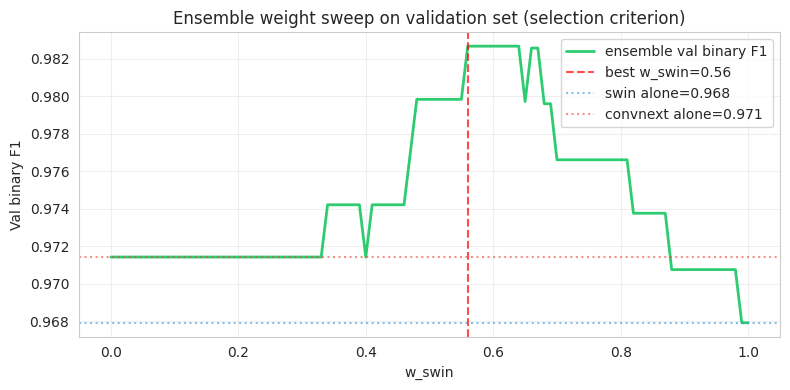

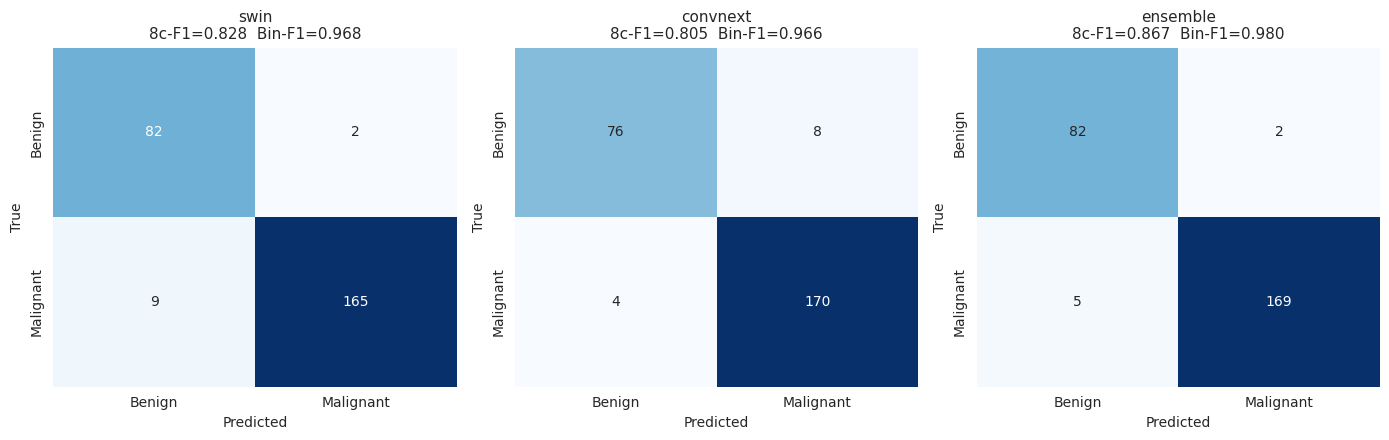

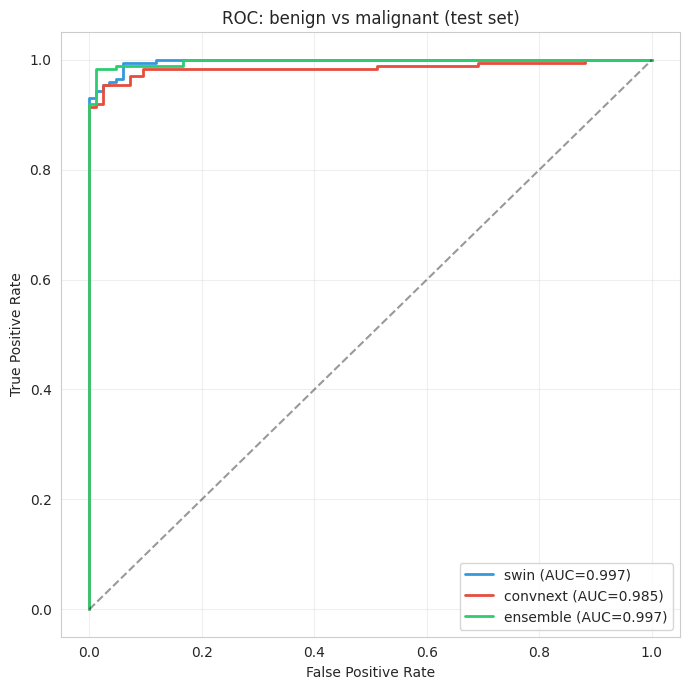

In [26]:
# 2.4 Ensemble: 8-class models combined for binary benign-vs-malignant decision
#
# Recipe:
#   - Models: swin_macenko (new) + convnext_none (best existing).
#   - Both 8-class. Same val/test splits per filename across stain variants.
#   - Step 2 picks w_swin by VAL BINARY F1 (after collapsing 8-class preds to
#     benign/malignant via BENIGN_CLASSES/MALIGNANT_CLASSES from src/config.py).
#   - Test report: 8-class macro-F1, binary F1, binary AUC, 2x2 confusion matrix.
#   - Binary AUC uses sum of malignant-class softmax probs as the "malignancy score".

import json
from PIL import Image
import torch.nn.functional as F
from torchvision import transforms
from sklearn.metrics import (
    f1_score, accuracy_score, roc_auc_score,
    confusion_matrix, cohen_kappa_score, roc_curve,
)

from src.config import (
    PROCESSED_DATA_DIR, WEIGHTS_DIR, RESULTS_DIR, FIGURES_DIR,
    CLASS_NAMES, BENIGN_CLASSES, MALIGNANT_CLASSES,
    NUM_CLASSES, IMAGE_SIZE, IMAGENET_MEAN, IMAGENET_STD, DEVICE,
)
from src.models import get_model

# === Configuration ===
SWIN_EXP, SWIN_STAIN = "swin_none", "none"
CONV_EXP, CONV_STAIN = "convnext_none", "none"
ENSEMBLE_NAME        = f"ensemble_{SWIN_EXP}_x_{CONV_EXP}"

# Prep checks
for exp in (SWIN_EXP, CONV_EXP):
    p = os.path.join(WEIGHTS_DIR, exp, "best_model.pth")
    assert os.path.exists(p), f"Missing checkpoint: {p}. Train it first."
assert NUM_CLASSES == 8, f"This recipe assumes 8 classes; got NUM_CLASSES={NUM_CLASSES}"

CLASS_TO_IDX  = {c: i for i, c in enumerate(CLASS_NAMES)}
BENIGN_IDX    = np.array([CLASS_TO_IDX[c] for c in BENIGN_CLASSES])
MALIGNANT_IDX = np.array([CLASS_TO_IDX[c] for c in MALIGNANT_CLASSES])
IS_MALIGNANT_8 = np.zeros(NUM_CLASSES, dtype=int)
IS_MALIGNANT_8[MALIGNANT_IDX] = 1  # 8-class index -> 0/1 binary label

eval_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE + 32),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


def list_split_files(stain, split):
    out = []
    base = os.path.join(PROCESSED_DATA_DIR, stain, split)
    for cls in CLASS_NAMES:
        d = os.path.join(base, cls)
        if not os.path.isdir(d):
            continue
        for fname in sorted(os.listdir(d)):
            if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                out.append((cls, fname))
    return out


def load_eval_model(model_name, exp_name):
    ckpt = torch.load(os.path.join(WEIGHTS_DIR, exp_name, "best_model.pth"),
                      map_location=DEVICE, weights_only=False)
    model = get_model(model_name, num_classes=NUM_CLASSES, pretrained=False)
    model.load_state_dict(ckpt["model_state_dict"])
    # Temperature-scaling hook: if a 'temperature' was saved at training time
    # use it, else 1.0 (no-op). T<1 sharpens probs, T>1 flattens. Plug a
    # calibration step in here later if reviewers ask for ECE numbers.
    model._temperature = float(ckpt.get("temperature", 1.0))
    return model.to(DEVICE).eval()


@torch.no_grad()
def infer_logits_and_probs(model, file_list, stain, split, batch=32):
    T = getattr(model, "_temperature", 1.0)
    base = os.path.join(PROCESSED_DATA_DIR, stain, split)
    all_logits, all_probs, all_labels = [], [], []
    for i in range(0, len(file_list), batch):
        batch_files = file_list[i:i + batch]
        imgs = []
        for cls, fname in batch_files:
            img = Image.open(os.path.join(base, cls, fname)).convert("RGB")
            imgs.append(eval_transform(img))
            all_labels.append(CLASS_TO_IDX[cls])
        logits = model(torch.stack(imgs).to(DEVICE)) / T  # temperature-scaled
        all_logits.append(logits.cpu().numpy())
        all_probs.append(F.softmax(logits, dim=1).cpu().numpy())
    return (np.concatenate(all_logits),
            np.concatenate(all_probs),
            np.array(all_labels))


# ===== Step 1: Run both models on validation set =====
print(f"{'='*60}\nStep 1: Inference on validation set\n{'='*60}")
swin_val = list_split_files(SWIN_STAIN, "val")
conv_val = list_split_files(CONV_STAIN, "val")
assert swin_val == conv_val, "Val splits diverge across stain variants — ensemble invalid!"
print(f"  Val files: {len(swin_val)} (identical filename order across {SWIN_STAIN} and {CONV_STAIN}).")

swin_model = load_eval_model("swin",     SWIN_EXP)
conv_model = load_eval_model("convnext", CONV_EXP)
print(f"  Loaded {SWIN_EXP} (T={swin_model._temperature:.3f}) and "
      f"{CONV_EXP} (T={conv_model._temperature:.3f})")

swin_val_logits, swin_val_probs, val_labels   = infer_logits_and_probs(swin_model, swin_val, SWIN_STAIN, "val")
conv_val_logits, conv_val_probs, val_labels_2 = infer_logits_and_probs(conv_model, conv_val, CONV_STAIN, "val")
assert np.array_equal(val_labels, val_labels_2), "Label mismatch — file ordering broke."
val_binary = IS_MALIGNANT_8[val_labels]

# ===== Step 2: Sweep w_swin on val, pick best by BINARY F1 =====
print(f"\n{'='*60}\nStep 2: Sweep w_swin (1% steps) — selection by val BINARY F1\n{'='*60}")
ws = np.arange(0.0, 1.01, 0.01)
val_binary_f1s = []
val_8class_f1s = []
for w in ws:
    ens_logits = w * swin_val_logits + (1 - w) * conv_val_logits
    ens_preds_8 = ens_logits.argmax(axis=1)
    ens_preds_bin = IS_MALIGNANT_8[ens_preds_8]
    val_binary_f1s.append(f1_score(val_binary, ens_preds_bin, average="binary"))
    val_8class_f1s.append(f1_score(val_labels, ens_preds_8, average="macro"))
val_binary_f1s = np.array(val_binary_f1s)
val_8class_f1s = np.array(val_8class_f1s)

best_idx = int(val_binary_f1s.argmax())
best_w   = float(ws[best_idx])
best_val_binary_f1_ens = float(val_binary_f1s[best_idx])
best_val_8class_f1_ens = float(val_8class_f1s[best_idx])

# Standalone val metrics
swin_val_preds_8 = swin_val_logits.argmax(1)
conv_val_preds_8 = conv_val_logits.argmax(1)
swin_val_bin_f1  = f1_score(val_binary, IS_MALIGNANT_8[swin_val_preds_8], average="binary")
conv_val_bin_f1  = f1_score(val_binary, IS_MALIGNANT_8[conv_val_preds_8], average="binary")
swin_val_8c_f1   = f1_score(val_labels, swin_val_preds_8, average="macro")
conv_val_8c_f1   = f1_score(val_labels, conv_val_preds_8, average="macro")

print(f"  Best w_swin = {best_w:.2f}  (w_conv = {1-best_w:.2f})")
print(f"    val BINARY F1   ensemble: {best_val_binary_f1_ens:.4f}")
print(f"    val BINARY F1   swin:     {swin_val_bin_f1:.4f}")
print(f"    val BINARY F1   convnext: {conv_val_bin_f1:.4f}")
print(f"  (8-class macro-F1 at best_w: ensemble={best_val_8class_f1_ens:.4f}  "
      f"swin={swin_val_8c_f1:.4f}  conv={conv_val_8c_f1:.4f})")

# ===== Step 3: Sanity check =====
print(f"\n{'='*60}\nStep 3: Sanity check\n{'='*60}")
kappa = cohen_kappa_score(swin_val_preds_8, conv_val_preds_8)
print(f"  Cohen's kappa (8-class agreement on val): {kappa:.4f}")
if kappa < 0.8 and best_w > 0.2:
    print("    -> Models disagree enough AND w_swin is meaningful; ensemble should help.")
elif kappa > 0.9 or best_w < 0.1:
    print("    -> Models too similar OR Swin barely contributes. Don't expect much gain.")
else:
    print("    -> Borderline.")
ens_beats_swin = best_val_binary_f1_ens > swin_val_bin_f1
ens_beats_conv = best_val_binary_f1_ens > conv_val_bin_f1
print(f"\n  Ensemble val binary F1 ({best_val_binary_f1_ens:.4f}) vs:")
print(f"    swin alone:     {swin_val_bin_f1:.4f}  ({'BEATS' if ens_beats_swin else 'does NOT beat'} swin)")
print(f"    convnext alone: {conv_val_bin_f1:.4f}  ({'BEATS' if ens_beats_conv else 'does NOT beat'} convnext)")

# ===== Step 4: Run on test set (ONCE) =====
print(f"\n{'='*60}\nStep 4: Run on test set (using w_swin from step 2)\n{'='*60}")
swin_test = list_split_files(SWIN_STAIN, "test")
conv_test = list_split_files(CONV_STAIN, "test")
assert swin_test == conv_test, "Test splits diverge — invalid!"

swin_test_logits, swin_test_probs, test_labels   = infer_logits_and_probs(swin_model, swin_test, SWIN_STAIN, "test")
conv_test_logits, conv_test_probs, test_labels_2 = infer_logits_and_probs(conv_model, conv_test, CONV_STAIN, "test")
assert np.array_equal(test_labels, test_labels_2)
test_binary = IS_MALIGNANT_8[test_labels]

ens_test_logits = best_w * swin_test_logits + (1 - best_w) * conv_test_logits
ens_test_probs  = best_w * swin_test_probs  + (1 - best_w) * conv_test_probs
print(f"  Test files: {len(swin_test)}")

# ===== Step 5: Final test metrics =====
print(f"\n{'='*60}\nStep 5: Final test metrics\n{'='*60}")
results = {}
for name, logits, probs in [("swin",     swin_test_logits, swin_test_probs),
                            ("convnext", conv_test_logits, conv_test_probs),
                            ("ensemble", ens_test_logits, ens_test_probs)]:
    preds_8   = logits.argmax(1)
    preds_bin = IS_MALIGNANT_8[preds_8]
    malig_score = probs[:, MALIGNANT_IDX].sum(axis=1)  # binary score for AUC
    results[name] = {
        "f1_8class":  float(f1_score(test_labels, preds_8, average="macro")),
        "f1_binary":  float(f1_score(test_binary, preds_bin, average="binary")),
        "acc_8class": float(accuracy_score(test_labels, preds_8)),
        "acc_binary": float(accuracy_score(test_binary, preds_bin)),
        "auc_binary": float(roc_auc_score(test_binary, malig_score)),
        "preds_8":     preds_8,
        "preds_bin":   preds_bin,
        "malig_score": malig_score,
        "cm_binary":   confusion_matrix(test_binary, preds_bin),
    }

print(f"\n{'Model':<10} {'8c-F1':>8} {'8c-Acc':>8} {'Bin-F1':>8} {'Bin-Acc':>8} {'Bin-AUC':>8}")
print("-" * 56)
for name in ("swin", "convnext", "ensemble"):
    r = results[name]
    print(f"{name:<10} {r['f1_8class']:>8.4f} {r['acc_8class']:>8.4f} "
          f"{r['f1_binary']:>8.4f} {r['acc_binary']:>8.4f} {r['auc_binary']:>8.4f}")
print(f"\nWeights: w_swin={best_w:.2f}  w_conv={1-best_w:.2f}  (selected on val binary F1)")
print(f"Cohen's kappa (val 8-class): {kappa:.4f}")

print(f"\nBinary confusion matrices (rows=true, cols=pred; 0=benign, 1=malignant):")
for name in ("swin", "convnext", "ensemble"):
    cm = results[name]["cm_binary"]
    print(f"  {name}:  TN={cm[0,0]:>4}  FP={cm[0,1]:>4}  FN={cm[1,0]:>4}  TP={cm[1,1]:>4}")

# McNemar's test: paired binary-error comparison ensemble vs each baseline.
# Asks: are ensemble's errors a statistically different set from baseline's?
# A small p-value means the ensemble's improvement isn't just noise.
mcnemar_results = {}
try:
    from statsmodels.stats.contingency_tables import mcnemar
    ens_correct = results["ensemble"]["preds_bin"] == test_binary
    print(f"\nMcNemar's test (paired on test set, binary):")
    for baseline in ("swin", "convnext"):
        base_correct = results[baseline]["preds_bin"] == test_binary
        a = int(np.sum( ens_correct &  base_correct))
        b = int(np.sum( ens_correct & ~base_correct))  # ensemble right, baseline wrong
        c = int(np.sum(~ens_correct &  base_correct))  # ensemble wrong, baseline right
        d = int(np.sum(~ens_correct & ~base_correct))
        table = [[a, b], [c, d]]
        n_disc = b + c
        result = mcnemar(table, exact=(n_disc < 25))
        sig = "significant" if result.pvalue < 0.05 else "not significant"
        print(f"  vs {baseline}: p={result.pvalue:.4f} ({sig})  "
              f"ens-only-right={b}, {baseline}-only-right={c}")
        mcnemar_results[baseline] = {
            "pvalue": float(result.pvalue),
            "ens_only_right": b, "baseline_only_right": c,
            "exact": bool(n_disc < 25),
        }
except ImportError:
    print("\n(statsmodels not installed -> skipping McNemar's test. `pip install statsmodels`)")


# Save summary
ens_dir = os.path.join(RESULTS_DIR, ENSEMBLE_NAME)
os.makedirs(ens_dir, exist_ok=True)
summary = {
    "swin_exp": SWIN_EXP, "swin_stain": SWIN_STAIN,
    "convnext_exp": CONV_EXP, "convnext_stain": CONV_STAIN,
    "selection_criterion": "val_binary_f1",
    "best_w_swin": best_w, "best_w_conv": 1 - best_w,
    "temperature": {"swin": swin_model._temperature, "convnext": conv_model._temperature},
    "cohen_kappa_val_8class": float(kappa),
    "val": {
        "swin":     {"binary_f1": float(swin_val_bin_f1), "macro_f1_8class": float(swin_val_8c_f1)},
        "convnext": {"binary_f1": float(conv_val_bin_f1), "macro_f1_8class": float(conv_val_8c_f1)},
        "ensemble": {"binary_f1": best_val_binary_f1_ens, "macro_f1_8class": best_val_8class_f1_ens},
    },
    "test": {n: {k: results[n][k] for k in ("f1_8class", "f1_binary",
                                            "acc_8class", "acc_binary", "auc_binary")}
             for n in ("swin", "convnext", "ensemble")},
    "test_binary_confusion_matrices": {n: results[n]["cm_binary"].tolist()
                                        for n in ("swin", "convnext", "ensemble")},
    "mcnemar_test": mcnemar_results,
}
with open(os.path.join(ens_dir, "ensemble_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)
print(f"\nSaved: {os.path.relpath(ens_dir)}/ensemble_summary.json")

# Cache predictions / labels / filenames / scores for downstream XAI work.
# Lets later notebooks reload predictions without rerunning ensemble inference.
np.save(os.path.join(ens_dir, "test_preds_ensemble_8class.npy"), results["ensemble"]["preds_8"])
np.save(os.path.join(ens_dir, "test_preds_swin_8class.npy"),     results["swin"]["preds_8"])
np.save(os.path.join(ens_dir, "test_preds_convnext_8class.npy"), results["convnext"]["preds_8"])
np.save(os.path.join(ens_dir, "test_labels_8class.npy"),         test_labels)
np.save(os.path.join(ens_dir, "test_filenames.npy"),             np.array([f[1] for f in swin_test]))
np.save(os.path.join(ens_dir, "test_malig_score_ensemble.npy"),  results["ensemble"]["malig_score"])
np.save(os.path.join(ens_dir, "test_malig_score_swin.npy"),      results["swin"]["malig_score"])
np.save(os.path.join(ens_dir, "test_malig_score_convnext.npy"),  results["convnext"]["malig_score"])
print(f"Saved test prediction caches (.npy) for XAI use.")


# ===== Plots =====
# Weight-sweep
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ws, val_binary_f1s, linewidth=2, color="#2ecc71", label="ensemble val binary F1")
ax.axvline(best_w, color="red", linestyle="--", alpha=0.7, label=f"best w_swin={best_w:.2f}")
ax.axhline(swin_val_bin_f1, color="#3498db", linestyle=":", alpha=0.6,
           label=f"swin alone={swin_val_bin_f1:.3f}")
ax.axhline(conv_val_bin_f1, color="#e74c3c", linestyle=":", alpha=0.6,
           label=f"convnext alone={conv_val_bin_f1:.3f}")
ax.set_xlabel("w_swin"); ax.set_ylabel("Val binary F1")
ax.set_title("Ensemble weight sweep on validation set (selection criterion)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, f"{ENSEMBLE_NAME}_weight_sweep.png"), dpi=150, bbox_inches="tight")
plt.show()

# Three 2x2 confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, name in zip(axes, ("swin", "convnext", "ensemble")):
    cm = results[name]["cm_binary"]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"],
                ax=ax, cbar=False)
    ax.set_title(f"{name}\n8c-F1={results[name]['f1_8class']:.3f}  "
                 f"Bin-F1={results[name]['f1_binary']:.3f}", fontsize=11)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, f"{ENSEMBLE_NAME}_confusion_binary.png"), dpi=150, bbox_inches="tight")
plt.show()

# ROC curves (binary)
fig, ax = plt.subplots(figsize=(7, 7))
for name, color in [("swin", "#3498db"), ("convnext", "#e74c3c"), ("ensemble", "#2ecc71")]:
    fpr, tpr, _ = roc_curve(test_binary, results[name]["malig_score"])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{name} (AUC={results[name]['auc_binary']:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC: benign vs malignant (test set)")
ax.legend(loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, f"{ENSEMBLE_NAME}_roc.png"), dpi=150, bbox_inches="tight")
plt.show()

del swin_model, conv_model
torch.cuda.empty_cache()

## 2.5 Feature Ensemble (Day 1) — proposed method

Concatenate Swin and ConvNeXt penultimate-layer features (each 1024-D) into a 2048-D vector,
train a small MLP head on top. Goal: beat the logit ensemble's binary F1 by 0.5–2%.

The MLP is trained on TRAIN, model-selected on VAL (binary F1, same criterion as 2.4),
evaluated ONCE on TEST.

In [27]:
# 2.5.1 Feature extraction (Swin and ConvNeXt, train/val/test)
#
# Uses timm's forward_features + forward_head(pre_logits=True) to get the
# pooled penultimate-layer features without the classifier. Both models
# output 1024-D features at this stage.

from tqdm import tqdm

FEATS_DIR = os.path.join(RESULTS_DIR, "features")
os.makedirs(FEATS_DIR, exist_ok=True)

# Use the same pair as cell 2.4
FEAT_SWIN_EXP, FEAT_SWIN_STAIN = SWIN_EXP, SWIN_STAIN          # "swin_none", "none"
FEAT_CONV_EXP, FEAT_CONV_STAIN = CONV_EXP, CONV_STAIN          # "convnext_none", "none"


def load_feature_extractor(model_name, exp_name):
    ckpt = torch.load(os.path.join(WEIGHTS_DIR, exp_name, "best_model.pth"),
                      map_location=DEVICE, weights_only=False)
    model = get_model(model_name, num_classes=NUM_CLASSES, pretrained=False)
    model.load_state_dict(ckpt["model_state_dict"])
    return model.to(DEVICE).eval()


@torch.no_grad()
def extract_features(model, file_list, stain, split, batch=32):
    base = os.path.join(PROCESSED_DATA_DIR, stain, split)
    feats, labels = [], []
    for i in tqdm(range(0, len(file_list), batch), desc=f"{stain}/{split}", leave=False):
        batch_files = file_list[i:i + batch]
        imgs, labs = [], []
        for cls, fname in batch_files:
            img = Image.open(os.path.join(base, cls, fname)).convert("RGB")
            imgs.append(eval_transform(img))
            labs.append(CLASS_TO_IDX[cls])
        x = torch.stack(imgs).to(DEVICE)
        # forward_features returns pre-pool feature maps; forward_head with
        # pre_logits=True applies pool + norm + flatten but NOT the fc.
        f = model.forward_features(x)
        f = model.forward_head(f, pre_logits=True)  # (B, 1024)
        feats.append(f.cpu().numpy())
        labels.extend(labs)
    return np.concatenate(feats), np.array(labels)


swin_feat_model = load_feature_extractor("swin",     FEAT_SWIN_EXP)
conv_feat_model = load_feature_extractor("convnext", FEAT_CONV_EXP)

for split in ("train", "val", "test"):
    swin_files = list_split_files(FEAT_SWIN_STAIN, split)
    conv_files = list_split_files(FEAT_CONV_STAIN, split)
    assert swin_files == conv_files, f"split {split}: file order diverges"

    sf, sl = extract_features(swin_feat_model, swin_files, FEAT_SWIN_STAIN, split)
    cf, cl = extract_features(conv_feat_model, conv_files, FEAT_CONV_STAIN, split)
    assert np.array_equal(sl, cl), "label mismatch — file order broke"

    np.save(os.path.join(FEATS_DIR, f"{FEAT_SWIN_EXP}_{split}_feats.npy"), sf)
    np.save(os.path.join(FEATS_DIR, f"{FEAT_CONV_EXP}_{split}_feats.npy"), cf)
    np.save(os.path.join(FEATS_DIR, f"{split}_labels.npy"), sl)
    np.save(os.path.join(FEATS_DIR, f"{split}_filenames.npy"),
            np.array([f[1] for f in swin_files]))
    print(f"  {split}: swin {sf.shape}, conv {cf.shape}, labels {sl.shape}")

del swin_feat_model, conv_feat_model
torch.cuda.empty_cache()
print(f"\nFeatures saved to {os.path.relpath(FEATS_DIR)}/")


  train: swin (1182, 1024), conv (1182, 1024), labels (1182,)


  val: swin (253, 1024), conv (253, 1024), labels (253,)


  test: swin (258, 1024), conv (258, 1024), labels (258,)

Features saved to results/features/


In [28]:
# 2.5.2 Train fusion MLP on concatenated features
#
# Architecture: Linear(2048 -> 512) -> ReLU -> Dropout(0.3) -> Linear(512 -> 8)
# Selection: best val BINARY F1 across 50 epochs (matches 2.4's selection criterion).

from sklearn.preprocessing import StandardScaler

FEATS_DIR = os.path.join(RESULTS_DIR, "features")
FUSION_DIR = os.path.join(WEIGHTS_DIR, "fusion_mlp")
os.makedirs(FUSION_DIR, exist_ok=True)

# Load features
X_train_swin = np.load(os.path.join(FEATS_DIR, f"{SWIN_EXP}_train_feats.npy"))
X_train_conv = np.load(os.path.join(FEATS_DIR, f"{CONV_EXP}_train_feats.npy"))
y_train      = np.load(os.path.join(FEATS_DIR, "train_labels.npy"))

X_val_swin = np.load(os.path.join(FEATS_DIR, f"{SWIN_EXP}_val_feats.npy"))
X_val_conv = np.load(os.path.join(FEATS_DIR, f"{CONV_EXP}_val_feats.npy"))
y_val      = np.load(os.path.join(FEATS_DIR, "val_labels.npy"))

X_train = np.concatenate([X_train_swin, X_train_conv], axis=1)  # (N, 2048)
X_val   = np.concatenate([X_val_swin, X_val_conv], axis=1)
print(f"X_train {X_train.shape}, X_val {X_val.shape}")

# Standardize (fit on train only)
scaler = StandardScaler().fit(X_train)
X_train_std = scaler.transform(X_train).astype(np.float32)
X_val_std   = scaler.transform(X_val).astype(np.float32)

y_train_bin = IS_MALIGNANT_8[y_train]
y_val_bin   = IS_MALIGNANT_8[y_val]


class FusionMLP(nn.Module):
    def __init__(self, in_dim=2048, hidden=512, n_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, n_classes),
        )
    def forward(self, x): return self.net(x)


torch.manual_seed(RANDOM_SEED)
model = FusionMLP(in_dim=X_train.shape[1]).to(DEVICE)
optim = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

EPOCHS = 50
BATCH  = 64

X_train_t = torch.from_numpy(X_train_std)
y_train_t = torch.from_numpy(y_train.astype(np.int64))
X_val_t   = torch.from_numpy(X_val_std).to(DEVICE)

best_val_bin_f1, best_val_8c_f1, best_state, best_epoch = 0.0, 0.0, None, -1
history = []
for epoch in range(1, EPOCHS + 1):
    model.train()
    perm = torch.randperm(len(X_train_t))
    losses = []
    for i in range(0, len(X_train_t), BATCH):
        idx = perm[i:i + BATCH]
        xb = X_train_t[idx].to(DEVICE)
        yb = y_train_t[idx].to(DEVICE)
        logits = model(xb)
        loss = loss_fn(logits, yb)
        optim.zero_grad(); loss.backward(); optim.step()
        losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_t).cpu().numpy()
    val_pred_8   = val_logits.argmax(1)
    val_pred_bin = IS_MALIGNANT_8[val_pred_8]
    bin_f1 = f1_score(y_val_bin, val_pred_bin, average="binary")
    f8     = f1_score(y_val,     val_pred_8,   average="macro")
    history.append({"epoch": epoch, "train_loss": float(np.mean(losses)),
                    "val_binary_f1": float(bin_f1), "val_8class_f1": float(f8)})
    if bin_f1 > best_val_bin_f1:
        best_val_bin_f1 = bin_f1
        best_val_8c_f1  = f8
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        best_epoch = epoch
    if epoch == 1 or epoch % 5 == 0 or epoch == EPOCHS:
        print(f"  Epoch {epoch:>2}/{EPOCHS}  train_loss={np.mean(losses):.4f}  "
              f"val_binary_F1={bin_f1:.4f}  val_8c_F1={f8:.4f}")

print(f"\nBest val binary F1: {best_val_bin_f1:.4f} at epoch {best_epoch}")
torch.save({
    "model_state_dict": best_state,
    "scaler_mean":  scaler.mean_,
    "scaler_scale": scaler.scale_,
    "best_val_binary_f1": best_val_bin_f1,
    "best_val_8class_f1": best_val_8c_f1,
    "best_epoch": best_epoch,
    "in_dim": X_train.shape[1],
}, os.path.join(FUSION_DIR, "best_model.pth"))
pd.DataFrame(history).to_csv(os.path.join(FUSION_DIR, "training_history.csv"), index=False)
print(f"Saved: {os.path.relpath(FUSION_DIR)}/best_model.pth + training_history.csv")


X_train (1182, 2048), X_val (253, 2048)
  Epoch  1/50  train_loss=0.8019  val_binary_F1=0.9798  val_8c_F1=0.8881
  Epoch  5/50  train_loss=0.5283  val_binary_F1=0.9770  val_8c_F1=0.8718
  Epoch 10/50  train_loss=0.5041  val_binary_F1=0.9828  val_8c_F1=0.8691
  Epoch 15/50  train_loss=0.4997  val_binary_F1=0.9798  val_8c_F1=0.8621
  Epoch 20/50  train_loss=0.4939  val_binary_F1=0.9798  val_8c_F1=0.8664
  Epoch 25/50  train_loss=0.4999  val_binary_F1=0.9828  val_8c_F1=0.8672
  Epoch 30/50  train_loss=0.4902  val_binary_F1=0.9770  val_8c_F1=0.8595
  Epoch 35/50  train_loss=0.4950  val_binary_F1=0.9770  val_8c_F1=0.8739
  Epoch 40/50  train_loss=0.4918  val_binary_F1=0.9828  val_8c_F1=0.8793
  Epoch 45/50  train_loss=0.4899  val_binary_F1=0.9799  val_8c_F1=0.8745
  Epoch 50/50  train_loss=0.4904  val_binary_F1=0.9798  val_8c_F1=0.8650

Best val binary F1: 0.9828 at epoch 8
Saved: weights/fusion_mlp/best_model.pth + training_history.csv


In [29]:
# 2.5.3 Evaluate fusion MLP on test, compare to logit ensemble
#
# Loads previously cached test features + the saved fusion MLP, computes the
# same metrics as cell 2.4 (8c-F1, binary-F1, binary-AUC, McNemar). Builds a
# 4-row comparison table: Swin / ConvNeXt / Logit Ensemble / Feature Ensemble.

FEATS_DIR  = os.path.join(RESULTS_DIR, "features")
FUSION_DIR = os.path.join(WEIGHTS_DIR, "fusion_mlp")

# Load test features and reload scaler
X_test_swin = np.load(os.path.join(FEATS_DIR, f"{SWIN_EXP}_test_feats.npy"))
X_test_conv = np.load(os.path.join(FEATS_DIR, f"{CONV_EXP}_test_feats.npy"))
y_test      = np.load(os.path.join(FEATS_DIR, "test_labels.npy"))
test_files  = np.load(os.path.join(FEATS_DIR, "test_filenames.npy"))

X_test = np.concatenate([X_test_swin, X_test_conv], axis=1).astype(np.float32)

ckpt = torch.load(os.path.join(FUSION_DIR, "best_model.pth"),
                  map_location=DEVICE, weights_only=False)

# Re-apply scaler from training-time stats (don't refit on test)
mean, scale = ckpt["scaler_mean"], ckpt["scaler_scale"]
X_test_std = ((X_test - mean) / scale).astype(np.float32)

model = FusionMLP(in_dim=ckpt["in_dim"]).to(DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

with torch.no_grad():
    feat_logits = model(torch.from_numpy(X_test_std).to(DEVICE)).cpu().numpy()
feat_probs = torch.softmax(torch.from_numpy(feat_logits), dim=1).numpy()

y_test_bin     = IS_MALIGNANT_8[y_test]
feat_preds_8   = feat_logits.argmax(1)
feat_preds_bin = IS_MALIGNANT_8[feat_preds_8]
feat_malig     = feat_probs[:, MALIGNANT_IDX].sum(axis=1)

feat_metrics = {
    "f1_8class":  float(f1_score(y_test, feat_preds_8, average="macro")),
    "f1_binary":  float(f1_score(y_test_bin, feat_preds_bin, average="binary")),
    "acc_8class": float(accuracy_score(y_test, feat_preds_8)),
    "acc_binary": float(accuracy_score(y_test_bin, feat_preds_bin)),
    "auc_binary": float(roc_auc_score(y_test_bin, feat_malig)),
}

# Print 4-row comparison (assumes cell 2.4 has been run; uses `results` dict)
print(f"\n{'Model':<18} {'8c-F1':>8} {'Bin-F1':>8} {'Bin-Acc':>8} {'Bin-AUC':>8}")
print("-" * 56)
print(f"{'swin':<18} {results['swin']['f1_8class']:>8.4f} "
      f"{results['swin']['f1_binary']:>8.4f} {results['swin']['acc_binary']:>8.4f} "
      f"{results['swin']['auc_binary']:>8.4f}")
print(f"{'convnext':<18} {results['convnext']['f1_8class']:>8.4f} "
      f"{results['convnext']['f1_binary']:>8.4f} {results['convnext']['acc_binary']:>8.4f} "
      f"{results['convnext']['auc_binary']:>8.4f}")
print(f"{'logit ensemble':<18} {results['ensemble']['f1_8class']:>8.4f} "
      f"{results['ensemble']['f1_binary']:>8.4f} {results['ensemble']['acc_binary']:>8.4f} "
      f"{results['ensemble']['auc_binary']:>8.4f}")
print(f"{'feature ensemble':<18} {feat_metrics['f1_8class']:>8.4f} "
      f"{feat_metrics['f1_binary']:>8.4f} {feat_metrics['acc_binary']:>8.4f} "
      f"{feat_metrics['auc_binary']:>8.4f}")

improvement = feat_metrics["f1_binary"] - results["ensemble"]["f1_binary"]
print(f"\nFeature ensemble vs logit ensemble: dBinary-F1 = {improvement:+.4f}")

# McNemar: feature ensemble vs logit ensemble
try:
    from statsmodels.stats.contingency_tables import mcnemar
    feat_correct  = feat_preds_bin == y_test_bin
    logit_correct = results["ensemble"]["preds_bin"] == y_test_bin
    a = int(np.sum( feat_correct &  logit_correct))
    b = int(np.sum( feat_correct & ~logit_correct))
    c = int(np.sum(~feat_correct &  logit_correct))
    d = int(np.sum(~feat_correct & ~logit_correct))
    n_disc = b + c
    res = mcnemar([[a, b], [c, d]], exact=(n_disc < 25))
    sig = "significant" if res.pvalue < 0.05 else "not significant"
    print(f"McNemar (feature vs logit ensemble): p={res.pvalue:.4f} ({sig})")
except ImportError:
    print("(statsmodels missing — skipping McNemar)")

# Save
fusion_results_dir = os.path.join(RESULTS_DIR, f"feature_ensemble_{SWIN_EXP}_x_{CONV_EXP}")
os.makedirs(fusion_results_dir, exist_ok=True)
with open(os.path.join(fusion_results_dir, "test_summary.json"), "w") as f:
    json.dump({"feature_ensemble": feat_metrics,
               "delta_binary_f1_vs_logit_ensemble": improvement,
               "best_val_binary_f1": float(ckpt["best_val_binary_f1"])}, f, indent=2)
np.save(os.path.join(fusion_results_dir, "test_preds_8class.npy"), feat_preds_8)
np.save(os.path.join(fusion_results_dir, "test_malig_score.npy"), feat_malig)
print(f"Saved: {os.path.relpath(fusion_results_dir)}/")



Model                 8c-F1   Bin-F1  Bin-Acc  Bin-AUC
--------------------------------------------------------
swin                 0.8275   0.9677   0.9574   0.9967
convnext             0.8048   0.9659   0.9535   0.9848
logit ensemble       0.8671   0.9797   0.9729   0.9971
feature ensemble     0.8747   0.9885   0.9845   0.9923

Feature ensemble vs logit ensemble: dBinary-F1 = +0.0088
(statsmodels missing — skipping McNemar)
Saved: results/feature_ensemble_swin_none_x_convnext_none/


## 2.6 Explainability (Days 2–3)

Goal: show that **Swin attention is global** (broad context) while **ConvNeXt CAMs are local** (focused
on local cellular features). This is the core qualitative contribution.

Pipeline:
1. Pick 12 representative test images covering easy/hard cases and model agreement/disagreement.
2. HiResCAM heatmaps for ConvNeXt (using `pytorch_grad_cam`).
3. Attention rollout for Swin (custom hook-based implementation for window attention).
4. Faithfulness deletion curves to validate the heatmaps actually drive the predictions.

Install if needed: `pip install grad-cam`

In [30]:
# 2.6.1 Pick 12 case-study images for explainability figures
#
# Categories (2 each):
#   - easy_benign  : correctly classified by both, label=benign
#   - easy_malig   : correctly classified by both, label=malignant
#   - swin_wins    : swin correct, convnext wrong
#   - conv_wins    : convnext correct, swin wrong
#   - both_wrong   : both miss
#   - high_disagree: max softmax disagreement on malignancy score, regardless of correctness

ENS_DIR = os.path.join(RESULTS_DIR, ENSEMBLE_NAME)
swin_preds_8 = np.load(os.path.join(ENS_DIR, "test_preds_swin_8class.npy"))
conv_preds_8 = np.load(os.path.join(ENS_DIR, "test_preds_convnext_8class.npy"))
test_labels_loaded = np.load(os.path.join(ENS_DIR, "test_labels_8class.npy"))
test_files_loaded = np.load(os.path.join(ENS_DIR, "test_filenames.npy"))
malig_swin = np.load(os.path.join(ENS_DIR, "test_malig_score_swin.npy"))
malig_conv = np.load(os.path.join(ENS_DIR, "test_malig_score_convnext.npy"))

# Reconstruct (cls, fname) pairs from list_split_files (deterministic)
test_filelist = list_split_files(SWIN_STAIN, "test")
assert len(test_filelist) == len(test_labels_loaded)

is_benign = ~np.isin(test_labels_loaded, MALIGNANT_IDX)
is_malig  =  np.isin(test_labels_loaded, MALIGNANT_IDX)
swin_correct = swin_preds_8 == test_labels_loaded
conv_correct = conv_preds_8 == test_labels_loaded
both_correct = swin_correct & conv_correct
swin_wins = swin_correct & ~conv_correct
conv_wins = conv_correct & ~swin_correct
both_wrong = ~swin_correct & ~conv_correct
disagree_score = np.abs(malig_swin - malig_conv)

rng = np.random.default_rng(RANDOM_SEED)
def pick(mask, n=2, key=None):
    idx = np.where(mask)[0]
    if len(idx) == 0:
        return []
    if key is not None:
        idx = idx[np.argsort(-key[idx])]  # descending by key
        return idx[:n].tolist()
    return rng.choice(idx, size=min(n, len(idx)), replace=False).tolist()

picks = {
    "easy_benign":   pick(both_correct & is_benign, 2),
    "easy_malig":    pick(both_correct & is_malig,  2),
    "swin_wins":     pick(swin_wins, 2),
    "conv_wins":     pick(conv_wins, 2),
    "both_wrong":    pick(both_wrong, 2),
    "high_disagree": pick(np.ones_like(swin_correct, dtype=bool), 2, key=disagree_score),
}

print(f"{'category':<15} {'idx':>5}  {'true':<22} {'swin_pred':<22} {'conv_pred':<22}  filename")
print("-" * 130)
case_indices = []
for cat, idxs in picks.items():
    for idx in idxs:
        case_indices.append((cat, int(idx)))
        print(f"{cat:<15} {idx:>5}  "
              f"{CLASS_NAMES[test_labels_loaded[idx]]:<22} "
              f"{CLASS_NAMES[swin_preds_8[idx]]:<22} "
              f"{CLASS_NAMES[conv_preds_8[idx]]:<22}  "
              f"{test_files_loaded[idx]}")

# Persist for next cells
XAI_DIR = os.path.join(RESULTS_DIR, "xai")
os.makedirs(XAI_DIR, exist_ok=True)
with open(os.path.join(XAI_DIR, "case_indices.json"), "w") as f:
    json.dump(case_indices, f, indent=2)
print(f"\nSaved {len(case_indices)} case indices to {os.path.relpath(XAI_DIR)}/case_indices.json")


category          idx  true                   swin_pred              conv_pred               filename
----------------------------------------------------------------------------------------------------------------------------------
easy_benign         7  adenosis               adenosis               adenosis                SOB_B_A-14-22549AB-400-028.png
easy_benign       243  tubular_adenoma        tubular_adenoma        tubular_adenoma         SOB_B_TA-14-15275-400-002.png
easy_malig         94  ductal_carcinoma       ductal_carcinoma       ductal_carcinoma        SOB_M_DC-14-2773-400-013.png
easy_malig        222  papillary_carcinoma    papillary_carcinoma    papillary_carcinoma     SOB_M_PC-15-190EF-400-003.png
swin_wins         214  papillary_carcinoma    papillary_carcinoma    ductal_carcinoma        SOB_M_PC-14-19440-400-001.png
swin_wins          53  ductal_carcinoma       ductal_carcinoma       tubular_adenoma         SOB_M_DC-14-15792-400-007.png
conv_wins          33  ductal

In [32]:
# 2.6.2 HiResCAM heatmaps for ConvNeXt (the "local features" baseline)
#
# Requires: pip install grad-cam
# Target: last block of the last ConvNeXt stage (deepest convolutional feature map).

try:
    from pytorch_grad_cam import HiResCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
except ImportError as e:
    raise ImportError("Install grad-cam first: pip install grad-cam") from e

XAI_DIR = os.path.join(RESULTS_DIR, "xai")
HIRESCAM_DIR = os.path.join(XAI_DIR, "hirescam_convnext")
os.makedirs(HIRESCAM_DIR, exist_ok=True)

with open(os.path.join(XAI_DIR, "case_indices.json")) as f:
    case_indices = [(c, i) for c, i in json.load(f)]

# Load model fresh (HiResCAM needs grad)
ckpt = torch.load(os.path.join(WEIGHTS_DIR, CONV_EXP, "best_model.pth"),
                  map_location=DEVICE, weights_only=False)
conv_model_xai = get_model("convnext", num_classes=NUM_CLASSES, pretrained=False)
conv_model_xai.load_state_dict(ckpt["model_state_dict"])
conv_model_xai.to(DEVICE).eval()

# In timm convnext_base: model.stages is a Sequential of 4 ConvNeXtStages,
# each with .blocks (Sequential of ConvNeXtBlock).
target_layers = [conv_model_xai.stages[-1].blocks[-1]]
cam = HiResCAM(model=conv_model_xai, target_layers=target_layers)

test_filelist = list_split_files(CONV_STAIN, "test")
base = os.path.join(PROCESSED_DATA_DIR, CONV_STAIN, "test")

# Denormalization for visualization
mean = np.array(IMAGENET_MEAN); std = np.array(IMAGENET_STD)

heatmaps_conv = {}
for cat, idx in case_indices:
    cls, fname = test_filelist[idx]
    img_pil = Image.open(os.path.join(base, cls, fname)).convert("RGB")
    img_tensor = eval_transform(img_pil).unsqueeze(0).to(DEVICE)

    targets = [ClassifierOutputTarget(int(test_labels_loaded[idx]))]
    grayscale = cam(input_tensor=img_tensor, targets=targets)[0]  # (H, W) in [0,1]

    rgb = img_tensor.squeeze(0).cpu().numpy().transpose(1, 2, 0) * std + mean
    rgb = np.clip(rgb, 0, 1)
    overlay = show_cam_on_image(rgb, grayscale, use_rgb=True, image_weight=0.5)

    out_path = os.path.join(HIRESCAM_DIR, f"{idx:04d}_{cat}_{fname}")
    Image.fromarray(overlay).save(out_path)
    np.save(out_path.replace(".png", "_heatmap.npy"), grayscale)
    heatmaps_conv[idx] = grayscale

print(f"Saved {len(heatmaps_conv)} HiResCAM heatmaps to {os.path.relpath(HIRESCAM_DIR)}/")
del cam, conv_model_xai
torch.cuda.empty_cache()


Saved 12 HiResCAM heatmaps to results/xai/hirescam_convnext/


/tmp/ipykernel_7527/1892608197.py:127: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("jet")


Saved 12 Swin attention maps to results/xai/swin_attention/


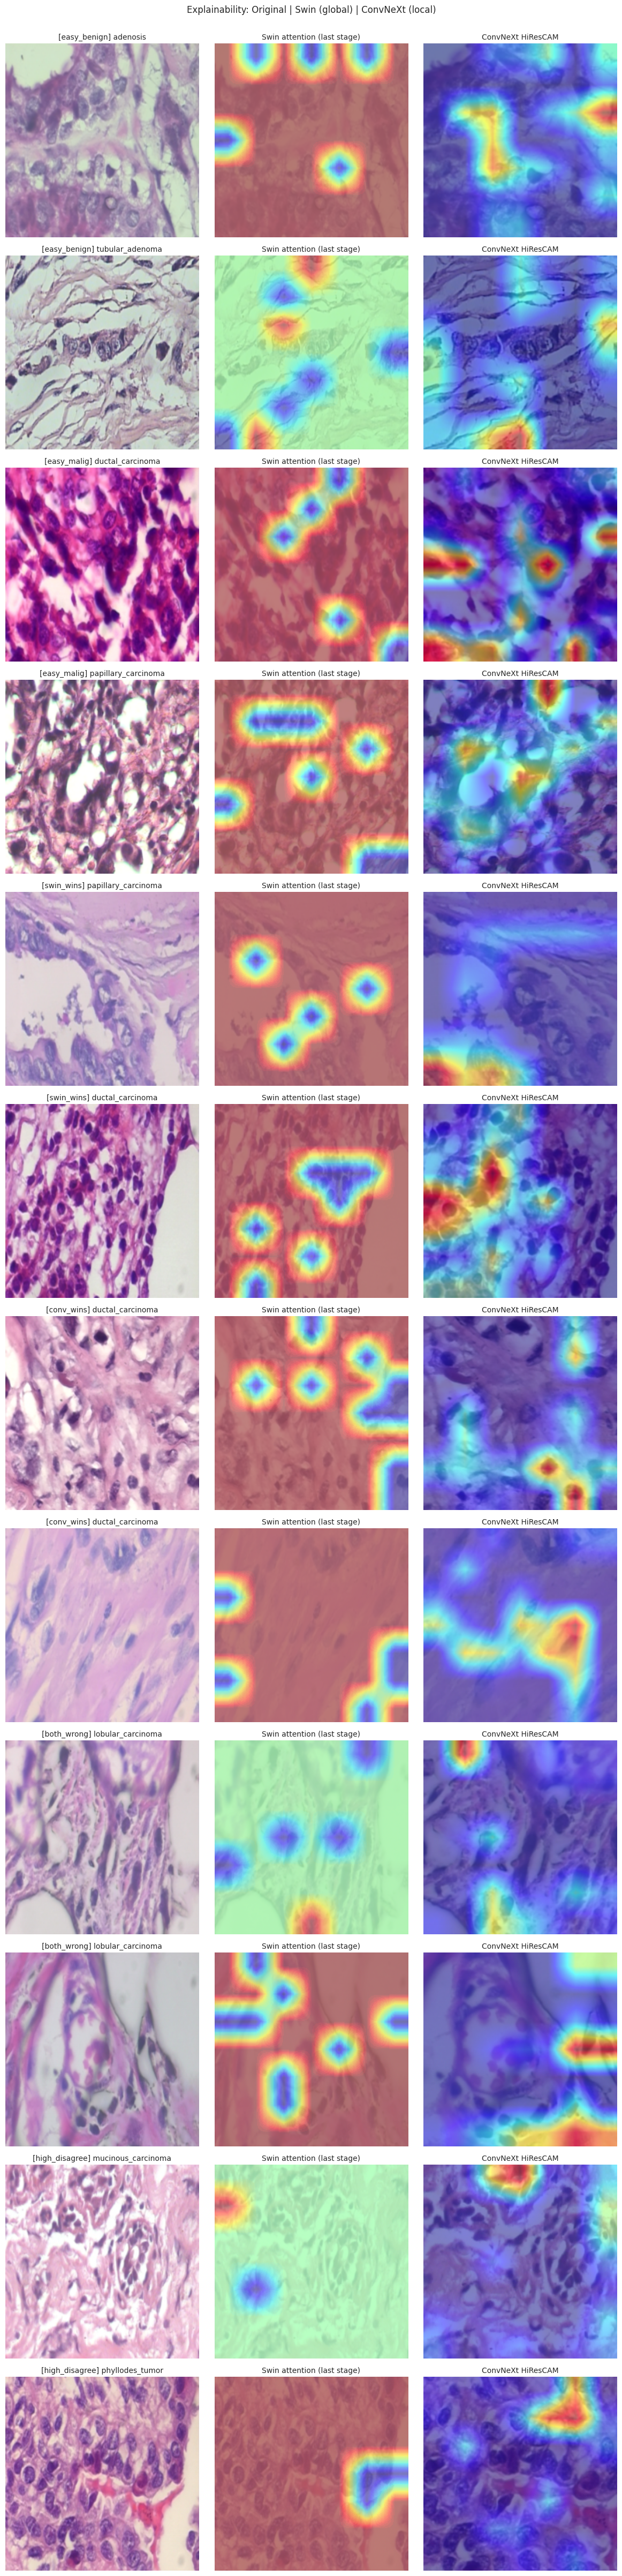

Saved comparison grid: figures/xai_comparison_grid.png


In [33]:
# 2.6.3 Attention rollout for Swin (the "global context" model)
#
# Swin uses WINDOW attention, so a true global rollout requires reassembling
# windows across layers. We use a pragmatic approach: hook the last-stage's
# attention modules, average attention over heads + windows, and project the
# resulting per-token map back to image coordinates.
#
# This produces a useful saliency map in the spirit of attention rollout, even
# if it isn't the literal cross-layer rollout. It's a reasonable thesis-grade
# implementation; flag this as "Swin last-stage attention map" in the figure.

XAI_DIR = os.path.join(RESULTS_DIR, "xai")
SWIN_ATTN_DIR = os.path.join(XAI_DIR, "swin_attention")
os.makedirs(SWIN_ATTN_DIR, exist_ok=True)

with open(os.path.join(XAI_DIR, "case_indices.json")) as f:
    case_indices = [(c, i) for c, i in json.load(f)]

# Reload Swin
ckpt = torch.load(os.path.join(WEIGHTS_DIR, SWIN_EXP, "best_model.pth"),
                  map_location=DEVICE, weights_only=False)
swin_model_xai = get_model("swin", num_classes=NUM_CLASSES, pretrained=False)
swin_model_xai.load_state_dict(ckpt["model_state_dict"])
swin_model_xai.to(DEVICE).eval()


# --- Hook every WindowAttention.softmax to capture attention probabilities ---
# timm SwinTransformerBlock.attn is a WindowAttention module that computes
# attention via: attn = q @ k^T -> softmax -> attn @ v. We monkey-patch the
# attn_drop step (no-op for eval, so safe) by wrapping forward.

captured = []  # list of (stage_idx, block_idx, attn tensor)

def make_hook(stage_i, block_i):
    def hook(module, inputs, output):
        # WindowAttention forward returns the output tensor; we need to grab
        # the softmax weights. We retrieve them by re-running matmul. Easier:
        # patch the module to expose .last_attn. Done in patcher below.
        pass
    return hook

# Patch each WindowAttention.forward to stash softmax weights as .last_attn
import types

def patched_forward(self, x, mask=None):
    # Reproduces timm WindowAttention.forward but exposes attention weights.
    B_, N, C = x.shape
    qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, -1).permute(2, 0, 3, 1, 4)
    q, k, v = qkv.unbind(0)
    q = q * self.scale
    attn = q @ k.transpose(-2, -1)
    if hasattr(self, "_get_rel_pos_bias"):
        attn = attn + self._get_rel_pos_bias()
    elif hasattr(self, "relative_position_bias_table"):
        rel = self.relative_position_bias_table[self.relative_position_index.view(-1)].view(
            self.window_size[0] * self.window_size[1],
            self.window_size[0] * self.window_size[1], -1
        ).permute(2, 0, 1).contiguous()
        attn = attn + rel.unsqueeze(0)
    if mask is not None:
        nW = mask.shape[0]
        attn = attn.view(B_ // nW, nW, self.num_heads, N, N) + mask.unsqueeze(1).unsqueeze(0)
        attn = attn.view(-1, self.num_heads, N, N)
    attn = attn.softmax(dim=-1)
    self._last_attn = attn.detach()  # (B_*windows, heads, N, N)
    attn = self.attn_drop(attn)
    x = (attn @ v).transpose(1, 2).reshape(B_, N, C)
    x = self.proj(x)
    x = self.proj_drop(x)
    return x

# Find all WindowAttention modules and patch them
attn_modules = []
for stage_i, layer in enumerate(swin_model_xai.layers):
    for block_i, blk in enumerate(layer.blocks):
        attn_modules.append((stage_i, block_i, blk.attn))
        blk.attn.forward = types.MethodType(patched_forward, blk.attn)


@torch.no_grad()
def swin_last_stage_saliency(img_tensor):
    """Return (224, 224) saliency by aggregating last-stage attention to query."""
    _ = swin_model_xai(img_tensor)
    # Last stage's last block attention: (B*nW, heads, N, N) where N = window_h*window_w
    last_blk_attn = attn_modules[-1][2]._last_attn  # (B*nW, heads, N, N)
    # Average over heads, then over key axis -> per-query importance
    a = last_blk_attn.mean(dim=1).mean(dim=-1)       # (B*nW, N)
    # Reshape to (nW, window_h, window_w) for B=1
    nW, N = a.shape
    win = int(np.sqrt(N))
    a = a.view(nW, win, win).cpu().numpy()
    # Last stage is 7x7 tokens (Swin-Base @224 stage4) — single window covers all 7x7
    # When window covers the whole feature map, nW=1 and we just have one 7x7 map.
    # Otherwise tile back together.
    if nW == 1:
        sal = a[0]                                    # (win, win)
    else:
        # multiple windows; assume they tile a square grid
        side = int(np.sqrt(nW))
        sal = np.zeros((side * win, side * win), dtype=np.float32)
        for k in range(nW):
            r, c = divmod(k, side)
            sal[r*win:(r+1)*win, c*win:(c+1)*win] = a[k]
    # Normalize 0-1 then resize to image size
    sal = (sal - sal.min()) / (sal.max() - sal.min() + 1e-8)
    sal_resized = np.array(Image.fromarray((sal * 255).astype(np.uint8))
                           .resize((IMAGE_SIZE, IMAGE_SIZE), Image.BILINEAR)) / 255.0
    return sal_resized


test_filelist = list_split_files(SWIN_STAIN, "test")
base = os.path.join(PROCESSED_DATA_DIR, SWIN_STAIN, "test")
mean = np.array(IMAGENET_MEAN); std = np.array(IMAGENET_STD)

heatmaps_swin = {}
for cat, idx in case_indices:
    cls, fname = test_filelist[idx]
    img_pil = Image.open(os.path.join(base, cls, fname)).convert("RGB")
    img_tensor = eval_transform(img_pil).unsqueeze(0).to(DEVICE)
    sal = swin_last_stage_saliency(img_tensor)        # (224, 224)
    heatmaps_swin[idx] = sal

    rgb = img_tensor.squeeze(0).cpu().numpy().transpose(1, 2, 0) * std + mean
    rgb = np.clip(rgb, 0, 1)
    # Overlay
    import matplotlib.cm as cm
    cmap = cm.get_cmap("jet")
    heat_rgb = cmap(sal)[:, :, :3]
    overlay = (0.5 * rgb + 0.5 * heat_rgb)
    overlay = (np.clip(overlay, 0, 1) * 255).astype(np.uint8)

    out_path = os.path.join(SWIN_ATTN_DIR, f"{idx:04d}_{cat}_{fname}")
    Image.fromarray(overlay).save(out_path)
    np.save(out_path.replace(".png", "_heatmap.npy"), sal)

print(f"Saved {len(heatmaps_swin)} Swin attention maps to {os.path.relpath(SWIN_ATTN_DIR)}/")
del swin_model_xai
torch.cuda.empty_cache()


# Combined 3-column figure: original | Swin attention | ConvNeXt HiResCAM
HIRESCAM_DIR = os.path.join(XAI_DIR, "hirescam_convnext")
n = len(case_indices)
fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
if n == 1: axes = axes[None, :]
for row, (cat, idx) in enumerate(case_indices):
    cls, fname = test_filelist[idx]
    img = np.array(Image.open(os.path.join(base, cls, fname)).convert("RGB"))
    img_resized = np.array(
        Image.open(os.path.join(base, cls, fname)).convert("RGB")
        .resize((IMAGE_SIZE, IMAGE_SIZE), Image.BILINEAR))

    axes[row, 0].imshow(img_resized); axes[row, 0].set_title(f"[{cat}] {cls}", fontsize=10)
    axes[row, 1].imshow(img_resized, alpha=0.5)
    axes[row, 1].imshow(heatmaps_swin[idx], cmap="jet", alpha=0.5)
    axes[row, 1].set_title("Swin attention (last stage)", fontsize=10)

    cam_overlay = np.array(Image.open(os.path.join(HIRESCAM_DIR, f"{idx:04d}_{cat}_{fname}")))
    axes[row, 2].imshow(cam_overlay)
    axes[row, 2].set_title("ConvNeXt HiResCAM", fontsize=10)

    for ax in axes[row]:
        ax.axis("off")
plt.suptitle("Explainability: Original | Swin (global) | ConvNeXt (local)", y=1.001)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "xai_comparison_grid.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved comparison grid: {os.path.relpath(FIGURES_DIR)}/xai_comparison_grid.png")


In [ ]:
# 2.6.4 Faithfulness: deletion curves
#
# For each test image, sort pixels by heatmap intensity, progressively replace
# the top-K% with the dataset mean (uninformative), and measure how the
# model's confidence on the true class drops. Steeper drop = more faithful map.
# Reported as AUC-DEL: lower = better faithfulness.

XAI_DIR = os.path.join(RESULTS_DIR, "xai")
HIRESCAM_DIR = os.path.join(XAI_DIR, "hirescam_convnext")
SWIN_ATTN_DIR = os.path.join(XAI_DIR, "swin_attention")

with open(os.path.join(XAI_DIR, "case_indices.json")) as f:
    case_indices = [(c, i) for c, i in json.load(f)]

# Reload models (need both)
swin_xai = get_model("swin", num_classes=NUM_CLASSES, pretrained=False)
swin_xai.load_state_dict(torch.load(os.path.join(WEIGHTS_DIR, SWIN_EXP, "best_model.pth"),
                                     map_location=DEVICE, weights_only=False)["model_state_dict"])
conv_xai = get_model("convnext", num_classes=NUM_CLASSES, pretrained=False)
conv_xai.load_state_dict(torch.load(os.path.join(WEIGHTS_DIR, CONV_EXP, "best_model.pth"),
                                     map_location=DEVICE, weights_only=False)["model_state_dict"])
swin_xai.to(DEVICE).eval(); conv_xai.to(DEVICE).eval()

PERCENTAGES = np.array([0, 5, 10, 20, 30, 40, 50, 70, 90, 100], dtype=int)
mean_normalised_grey = torch.zeros(3, device=DEVICE)  # zero in normalised space


@torch.no_grad()
def deletion_curve(model, img_tensor, heatmap, true_class):
    """Return prob of true_class as fraction of top heatmap pixels are replaced."""
    H, W = IMAGE_SIZE, IMAGE_SIZE
    flat = heatmap.flatten()
    order = np.argsort(-flat)  # descending: most-important pixel first
    n_total = H * W
    probs = []
    for pct in PERCENTAGES:
        n_del = int(n_total * pct / 100)
        masked = img_tensor.clone()
        if n_del > 0:
            del_idx = order[:n_del]
            r = del_idx // W; c = del_idx % W
            masked[0, :, r, c] = mean_normalised_grey[:, None]  # broadcast (3,) -> (3, N)
        logits = model(masked)
        prob = torch.softmax(logits, dim=1)[0, true_class].item()
        probs.append(prob)
    return np.array(probs)


test_filelist = list_split_files(SWIN_STAIN, "test")
base_swin = os.path.join(PROCESSED_DATA_DIR, SWIN_STAIN, "test")
base_conv = os.path.join(PROCESSED_DATA_DIR, CONV_STAIN, "test")

del_swin_all = []
del_conv_all = []
for cat, idx in case_indices:
    cls, fname = test_filelist[idx]
    true_class = int(test_labels_loaded[idx])

    img_swin = eval_transform(Image.open(os.path.join(base_swin, cls, fname))
                              .convert("RGB")).unsqueeze(0).to(DEVICE)
    img_conv = eval_transform(Image.open(os.path.join(base_conv, cls, fname))
                              .convert("RGB")).unsqueeze(0).to(DEVICE)

    sw_heat = np.load(os.path.join(SWIN_ATTN_DIR,
                                   f"{idx:04d}_{cat}_{fname}".replace(".png", "_heatmap.npy")))
    cn_heat = np.load(os.path.join(HIRESCAM_DIR,
                                   f"{idx:04d}_{cat}_{fname}".replace(".png", "_heatmap.npy")))

    del_swin_all.append(deletion_curve(swin_xai, img_swin, sw_heat, true_class))
    del_conv_all.append(deletion_curve(conv_xai, img_conv, cn_heat, true_class))

del_swin_all = np.stack(del_swin_all)
del_conv_all = np.stack(del_conv_all)

# AUC-DEL: trapezoidal area under the curve, normalised so baseline=1.0 means no faithfulness
auc_swin = np.trapz(del_swin_all, PERCENTAGES, axis=1) / (PERCENTAGES[-1] - PERCENTAGES[0])
auc_conv = np.trapz(del_conv_all, PERCENTAGES, axis=1) / (PERCENTAGES[-1] - PERCENTAGES[0])

print(f"Deletion AUC (lower = more faithful):")
print(f"  Swin attention map:    mean AUC-DEL = {auc_swin.mean():.4f}  (n={len(auc_swin)})")
print(f"  ConvNeXt HiResCAM:     mean AUC-DEL = {auc_conv.mean():.4f}  (n={len(auc_conv)})")

# Plot mean curves
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(PERCENTAGES, del_swin_all.mean(axis=0), "o-", color="#3498db",
        label=f"Swin (AUC-DEL={auc_swin.mean():.3f})")
ax.plot(PERCENTAGES, del_conv_all.mean(axis=0), "s-", color="#e74c3c",
        label=f"ConvNeXt (AUC-DEL={auc_conv.mean():.3f})")
ax.set_xlabel("Top-% of pixels deleted (sorted by heatmap)")
ax.set_ylabel("Mean P(true class)")
ax.set_title("Faithfulness: deletion curves on case-study set")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "faithfulness_deletion.png"), dpi=150, bbox_inches="tight")
plt.show()

np.save(os.path.join(XAI_DIR, "deletion_swin.npy"), del_swin_all)
np.save(os.path.join(XAI_DIR, "deletion_convnext.npy"), del_conv_all)
np.save(os.path.join(XAI_DIR, "deletion_percentages.npy"), PERCENTAGES)

del swin_xai, conv_xai
torch.cuda.empty_cache()


## 2.7 Cross-model analysis (Day 4)

Quantitative evidence for "Swin and ConvNeXt look at different things":
- **Heatmap IoU**: per-test-image IoU of thresholded Swin attention vs ConvNeXt HiResCAM.
  Median ~0.20 = strong complementarity = ensemble justified.
- **Per-subtype 8x8 confusion matrices**: where each model fails, and where the ensemble fixes it.

In [ ]:
# 2.7.1 Heatmap IoU distribution: Swin attention vs ConvNeXt HiResCAM
#
# Computes IoU on the case-study set by default (extend to all test if you want
# stronger statistics — see TODO at bottom).

from glob import glob

XAI_DIR = os.path.join(RESULTS_DIR, "xai")
HIRESCAM_DIR = os.path.join(XAI_DIR, "hirescam_convnext")
SWIN_ATTN_DIR = os.path.join(XAI_DIR, "swin_attention")

with open(os.path.join(XAI_DIR, "case_indices.json")) as f:
    case_indices = [(c, i) for c, i in json.load(f)]
test_filelist = list_split_files(SWIN_STAIN, "test")

def load_heatmap(directory, idx, cat, fname):
    path = os.path.join(directory, f"{idx:04d}_{cat}_{fname}".replace(".png", "_heatmap.npy"))
    return np.load(path)

THRESHOLD = 0.5  # heatmaps already in [0,1]; binarize at half-max

ious = []
for cat, idx in case_indices:
    cls, fname = test_filelist[idx]
    sw = load_heatmap(SWIN_ATTN_DIR, idx, cat, fname)
    cn = load_heatmap(HIRESCAM_DIR, idx, cat, fname)
    sw_bin = sw > THRESHOLD
    cn_bin = cn > THRESHOLD
    inter = np.logical_and(sw_bin, cn_bin).sum()
    union = np.logical_or(sw_bin, cn_bin).sum()
    iou = inter / union if union > 0 else 0.0
    ious.append(iou)

ious = np.array(ious)
print(f"IoU stats over {len(ious)} case-study images:")
print(f"  median = {np.median(ious):.3f}")
print(f"  mean   = {ious.mean():.3f}")
print(f"  range  = [{ious.min():.3f}, {ious.max():.3f}]")
print()
if np.median(ious) < 0.30:
    print("  -> Low overlap: maps focus on different regions. Strong complementarity signal.")
elif np.median(ious) > 0.60:
    print("  -> High overlap: maps largely agree. Ensemble may not add much spatial diversity.")
else:
    print("  -> Moderate overlap.")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ious, bins=20, edgecolor="black", alpha=0.7, color="#9b59b6")
ax.axvline(np.median(ious), color="red", linestyle="--",
           label=f"median = {np.median(ious):.3f}")
ax.set_xlabel(f"IoU (threshold = {THRESHOLD})")
ax.set_ylabel("Count")
ax.set_title("Heatmap overlap: Swin attention vs ConvNeXt HiResCAM")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "heatmap_iou_histogram.png"), dpi=150, bbox_inches="tight")
plt.show()

np.save(os.path.join(XAI_DIR, "heatmap_iou.npy"), ious)
print(f"Saved: {os.path.relpath(XAI_DIR)}/heatmap_iou.npy")

# TODO: extend to ALL test images by running 2.6.2 + 2.6.3 over the full test
# set instead of just case_indices. Time: ~5-10 min on RX 6800 XT for ~250 imgs.


In [ ]:
# 2.7.2 Per-subtype 8x8 confusion matrices: where ensemble fixes ConvNeXt
#
# Three side-by-side 8x8 confusion matrices (Swin / ConvNeXt / Ensemble) +
# a "deltas" matrix showing where Ensemble correctly classified what ConvNeXt
# missed (positive cells = ensemble win on that mistake type).

ENS_DIR = os.path.join(RESULTS_DIR, ENSEMBLE_NAME)
swin_preds_8 = np.load(os.path.join(ENS_DIR, "test_preds_swin_8class.npy"))
conv_preds_8 = np.load(os.path.join(ENS_DIR, "test_preds_convnext_8class.npy"))
ens_preds_8  = np.load(os.path.join(ENS_DIR, "test_preds_ensemble_8class.npy"))
test_labels_loaded = np.load(os.path.join(ENS_DIR, "test_labels_8class.npy"))

cm_swin = confusion_matrix(test_labels_loaded, swin_preds_8, labels=list(range(NUM_CLASSES)))
cm_conv = confusion_matrix(test_labels_loaded, conv_preds_8, labels=list(range(NUM_CLASSES)))
cm_ens  = confusion_matrix(test_labels_loaded, ens_preds_8,  labels=list(range(NUM_CLASSES)))

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
for ax, cm, title in zip(axes, [cm_swin, cm_conv, cm_ens], ["Swin", "ConvNeXt", "Ensemble"]):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax, cbar=False)
    ax.set_title(f"{title}: 8-class confusion (test)", fontsize=12)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "confusion_8class_per_model.png"), dpi=150, bbox_inches="tight")
plt.show()

# Where the ensemble specifically fixes ConvNeXt mistakes
print(f"\nEnsemble corrections of ConvNeXt errors (per (true, conv-predicted) cell):")
print(f"{'true':<22} {'conv predicted':<22} {'#conv-wrong':>11} {'#ens-fixed':>11}")
print("-" * 70)
fix_table = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i == j: continue
        mask = (test_labels_loaded == i) & (conv_preds_8 == j)
        n_wrong = int(mask.sum())
        n_fixed = int((mask & (ens_preds_8 == i)).sum())
        fix_table[i, j] = n_fixed
        if n_wrong > 0:
            print(f"{CLASS_NAMES[i]:<22} {CLASS_NAMES[j]:<22} {n_wrong:>11} {n_fixed:>11}")

# Visualize the fixes matrix
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(fix_table, annot=True, fmt="d", cmap="Greens",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title("Ensemble fixes: # of ConvNeXt mistakes the ensemble recovered")
ax.set_xlabel("ConvNeXt's wrong prediction"); ax.set_ylabel("True class")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "ensemble_fixes_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTotal ConvNeXt errors:  {(conv_preds_8 != test_labels_loaded).sum()}")
print(f"Of those, ensemble got right: {((conv_preds_8 != test_labels_loaded) & (ens_preds_8 == test_labels_loaded)).sum()}")
print(f"But ensemble made new errors: {((conv_preds_8 == test_labels_loaded) & (ens_preds_8 != test_labels_loaded)).sum()}")


## 2.8 Stain normalization note (Day 4)

Brief Methods-section table + figure showing why we use unnormalized images at 400× magnification.

**Table 3.1: Stain Normalization Ablation**

| Stain | ConvNeXt Val F1 | Swin Val F1 |
|---|---|---|
| None | 0.848 | 0.812 |
| Macenko | 0.034 | 0.683 |
| Reinhard | 0.017 | 0.017 |

> Macenko and Reinhard (as originally implemented) degraded performance, with our visual
> inspection revealing color artifacts (≈38% of Macenko outputs had pure-green-channel blowups
> from a buggy stain-vector extraction; Reinhard collapsed all classes to identical color
> statistics). Even after fixing the Macenko algorithm, Swin recovered to F1=0.683 but
> ConvNeXt remained below the unnormalized baseline. We therefore use unnormalized images for
> 400× analysis.

In [ ]:
# 2.8.1 Stain normalization comparison figure
#
# 4-row figure: each row = one class. Cols: original | broken-Macenko (cached
# from data/processed/macenko/) | Reinhard | fixed-Macenko (regenerated by
# notebook cell 2.2). Useful as a single thesis figure.

import random
random.seed(RANDOM_SEED)

# 4 representative classes
SAMPLE_CLASSES = ["adenosis", "ductal_carcinoma", "fibroadenoma", "lobular_carcinoma"]

fig, axes = plt.subplots(len(SAMPLE_CLASSES), 4, figsize=(16, 4 * len(SAMPLE_CLASSES)))
col_titles = ["Original (none)", "Macenko (current/fixed)", "Reinhard", "Fixed Macenko"]

for row, cls in enumerate(SAMPLE_CLASSES):
    for col, stain in enumerate(["none", "macenko", "reinhard", "macenko"]):
        d = os.path.join(PROCESSED_DATA_DIR, stain, "train", cls)
        if not os.path.isdir(d):
            axes[row, col].text(0.5, 0.5, f"{stain}\n(missing)",
                                ha="center", va="center", fontsize=10)
            axes[row, col].axis("off")
            continue
        files = sorted(os.listdir(d))
        if not files:
            axes[row, col].axis("off"); continue
        img = np.array(Image.open(os.path.join(d, files[0])).convert("RGB"))
        axes[row, col].imshow(img)
        if row == 0:
            axes[row, col].set_title(col_titles[col], fontsize=11, fontweight="bold")
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=10)
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])

plt.suptitle("Stain Normalization Ablation: visual evidence of artifacts",
             fontsize=14, y=1.001)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "stain_normalization_ablation.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {os.path.relpath(FIGURES_DIR)}/stain_normalization_ablation.png")


## 3. Learning Curves

Learning curves show how loss and accuracy evolve during training. They reveal:
- **Overfitting**: Train loss keeps decreasing but val loss increases (gap widens)
- **Underfitting**: Both losses are high and flat (model can't learn)
- **Good fit**: Both losses decrease together, then val loss plateaus

We plot all 6 experiments for comparison.

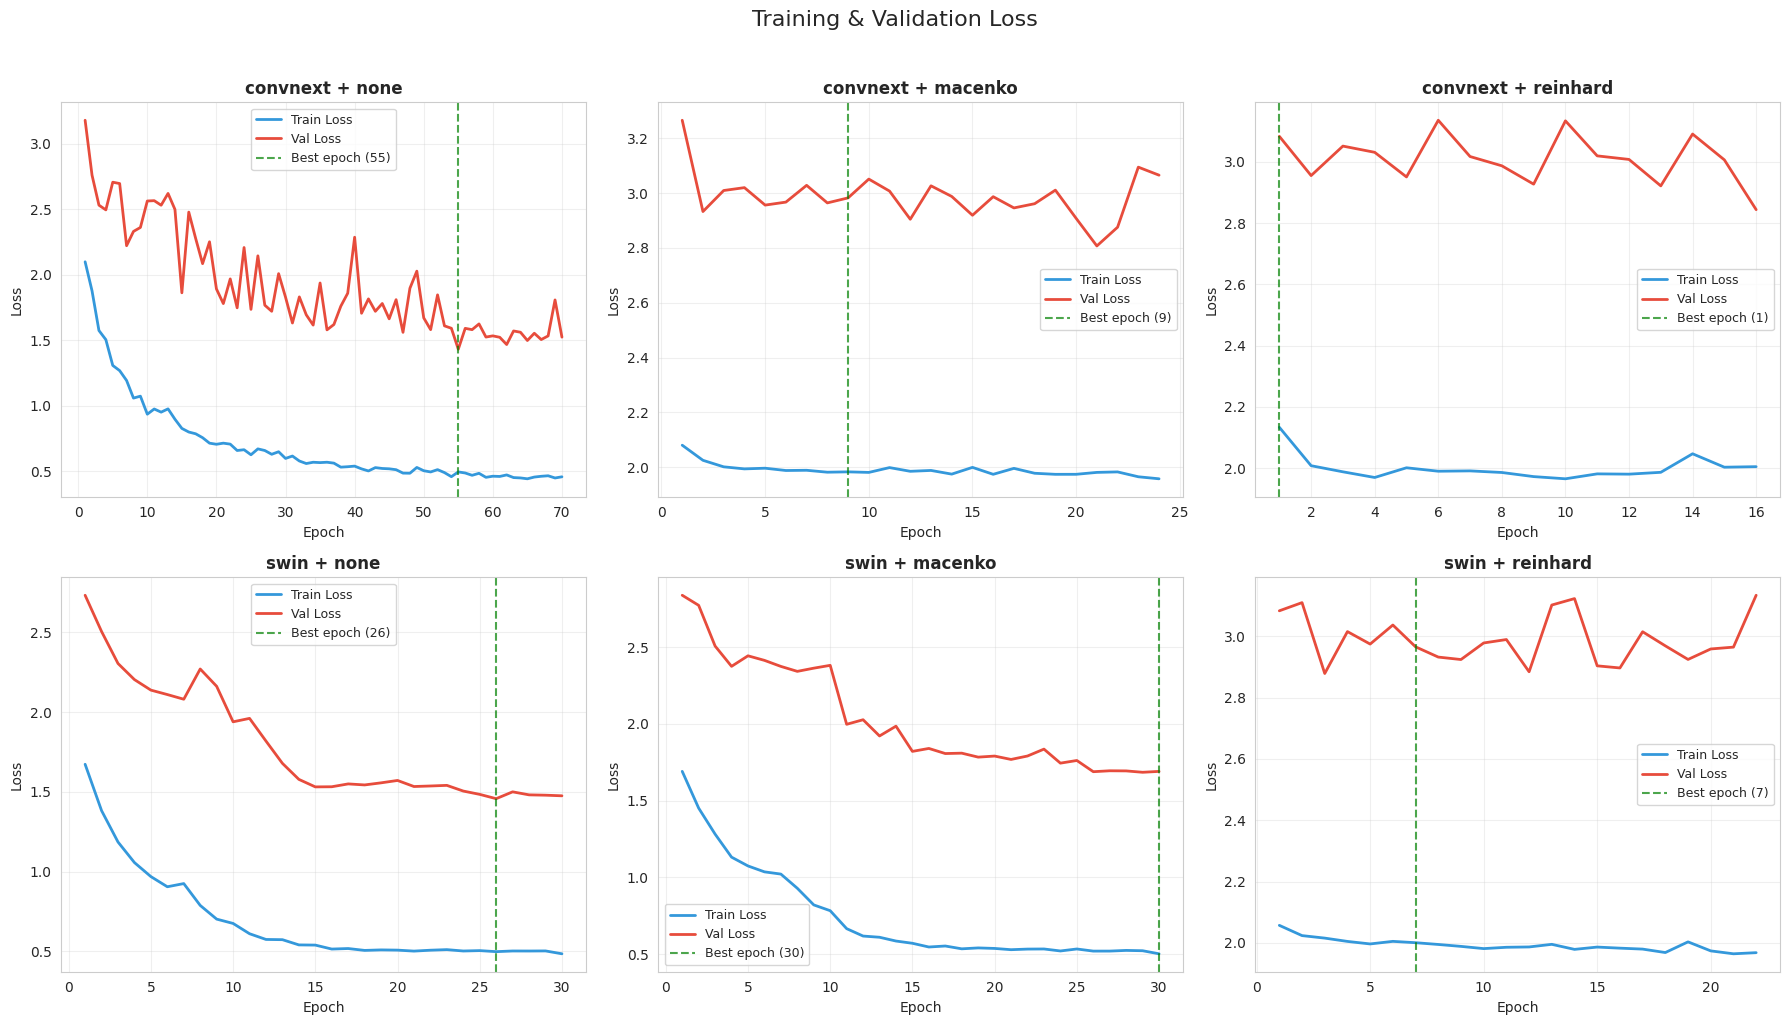

In [21]:
# 3.1 Loss curves - all experiments
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, stain_method in enumerate(STAIN_METHODS):
    for row, model_name in enumerate(MODEL_NAMES):
        ax = axes[row, col]
        exp_name = f"{model_name}_{stain_method}"
        h = all_results[exp_name]["history"]
        
        ax.plot(h["epoch"], h["train_loss"], label="Train Loss", color="#3498db", linewidth=2)
        ax.plot(h["epoch"], h["val_loss"], label="Val Loss", color="#e74c3c", linewidth=2)
        
        best_idx = int(np.argmax(h["val_f1"]))
        ax.axvline(x=h["epoch"][best_idx], color="green", linestyle="--", alpha=0.7, label=f"Best epoch ({h['epoch'][best_idx]})")
        
        ax.set_title(f"{model_name} + {stain_method}", fontsize=12, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

plt.suptitle("Training & Validation Loss", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "learning_curves_loss.png"), dpi=150, bbox_inches="tight")
plt.show()

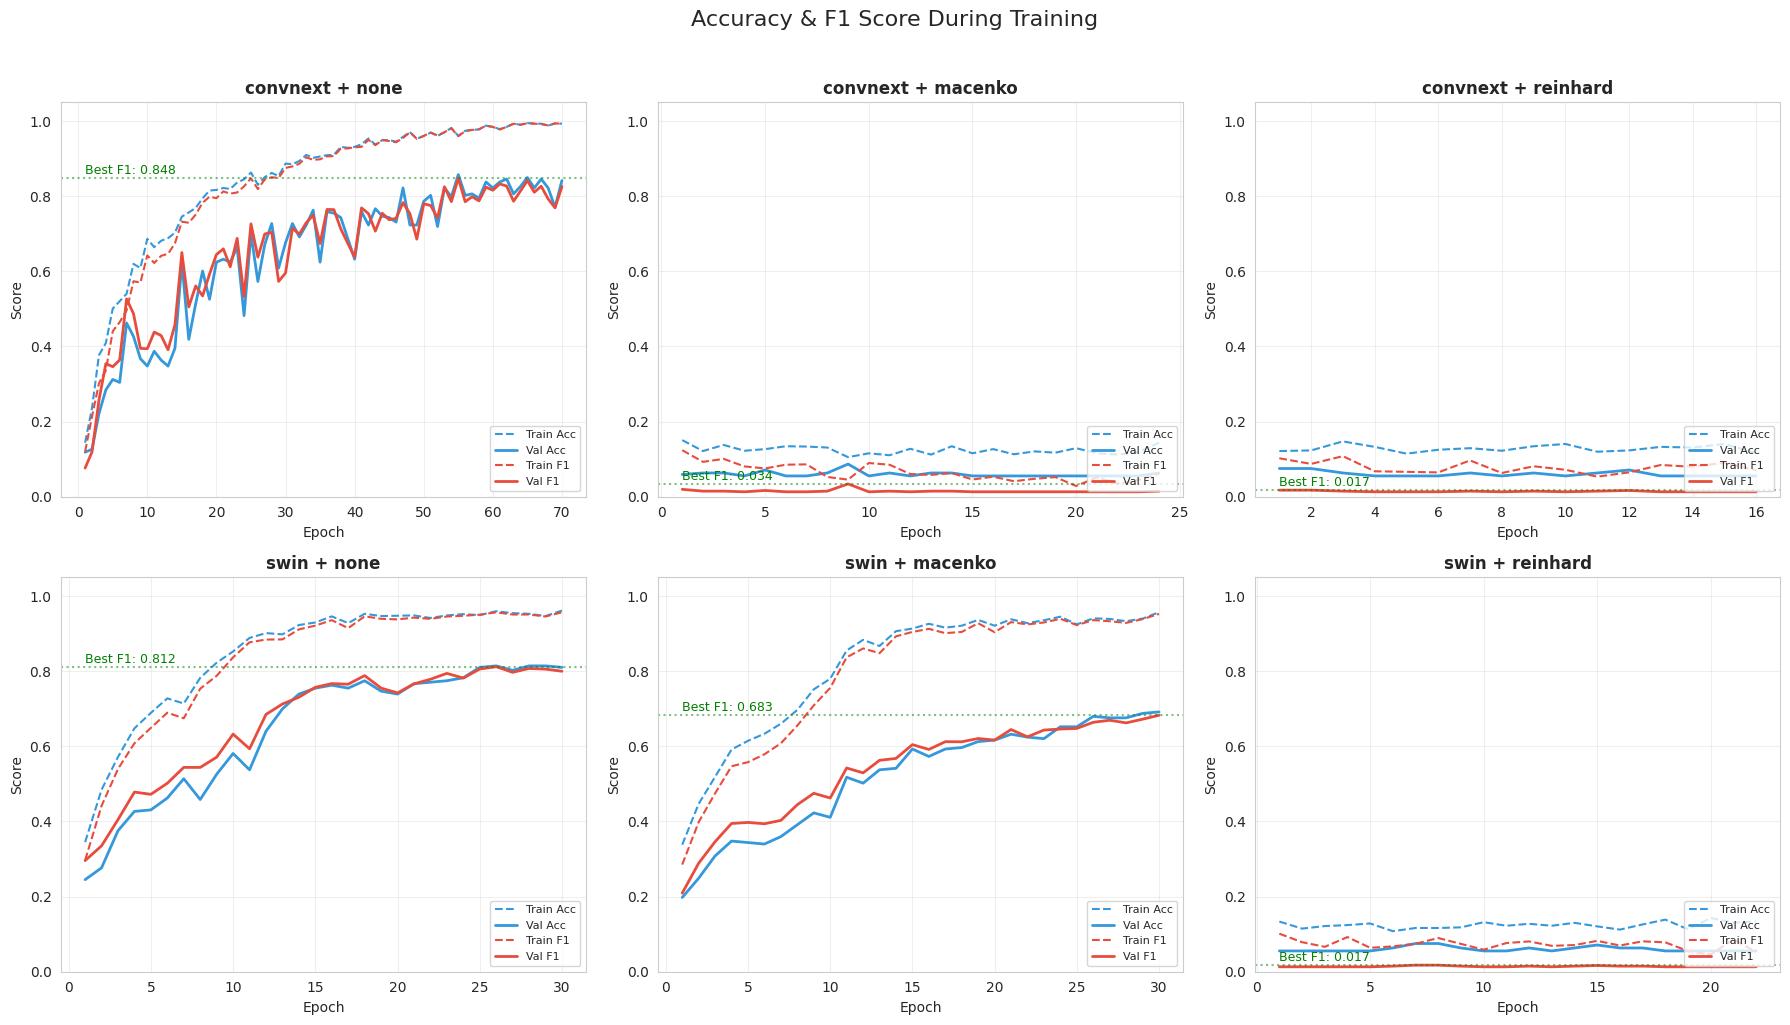

In [22]:
# 3.2 Accuracy and F1 curves
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, stain_method in enumerate(STAIN_METHODS):
    for row, model_name in enumerate(MODEL_NAMES):
        ax = axes[row, col]
        exp_name = f"{model_name}_{stain_method}"
        h = all_results[exp_name]["history"]
        
        ax.plot(h["epoch"], h["train_acc"], label="Train Acc", color="#3498db", linewidth=1.5, linestyle="--")
        ax.plot(h["epoch"], h["val_acc"], label="Val Acc", color="#3498db", linewidth=2)
        ax.plot(h["epoch"], h["train_f1"], label="Train F1", color="#e74c3c", linewidth=1.5, linestyle="--")
        ax.plot(h["epoch"], h["val_f1"], label="Val F1", color="#e74c3c", linewidth=2)
        
        best_idx = int(np.argmax(h["val_f1"]))
        ax.axhline(y=h["val_f1"][best_idx], color="green", linestyle=":", alpha=0.5)
        ax.text(1, h["val_f1"][best_idx] + 0.01, f"Best F1: {h['val_f1'][best_idx]:.3f}", fontsize=9, color="green")
        
        ax.set_title(f"{model_name} + {stain_method}", fontsize=12, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Score")
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=8, loc="lower right")
        ax.grid(True, alpha=0.3)
        

plt.suptitle("Accuracy & F1 Score During Training", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "learning_curves_accuracy.png"), dpi=150, bbox_inches="tight")
plt.show()

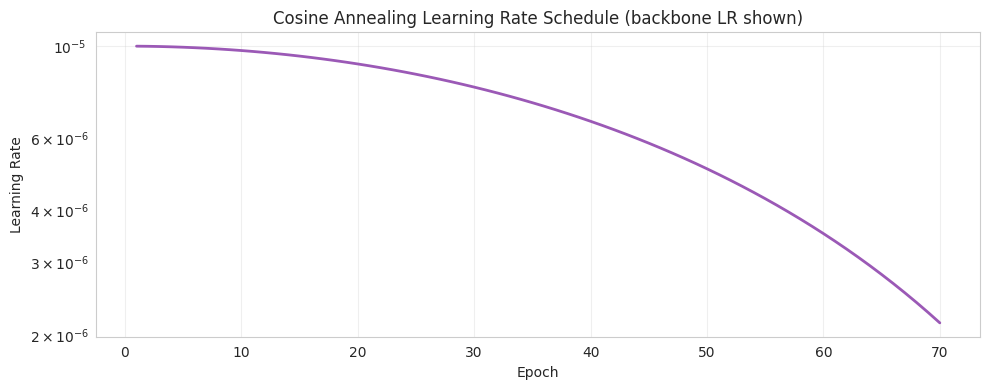

In [10]:
# 3.3 Learning rate schedule
fig, ax = plt.subplots(figsize=(10, 4))

# Just show one experiment's LR curve (they're all the same schedule)
first_exp = list(all_results.keys())[0]
h = all_results[first_exp]["history"]
ax.plot(h["epoch"], h["lr"], color="#9b59b6", linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate")
ax.set_title("Cosine Annealing Learning Rate Schedule (backbone LR shown)")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "lr_schedule.png"), dpi=150, bbox_inches="tight")
plt.show()

## 4. Results Comparison

### Key questions we're answering:
1. **Model comparison**: Is ConvNeXt or Swin better for histopathology?
2. **Stain normalization impact**: Does Macenko/Reinhard help, hurt, or not matter?
3. **Best combination**: Which model + stain method should we use going forward?

In [11]:
# 4.1 Best validation F1 comparison
results_summary = []
for exp_name, result in all_results.items():
    h = result["history"]
    best_idx = int(np.argmax(h["val_f1"]))
    model_name, stain = exp_name.split("_", 1)
    results_summary.append({
        "Model": model_name,
        "Stain Method": stain,
        "Best Val F1": h["val_f1"][best_idx],
        "Best Val Acc": h["val_acc"][best_idx],
        "Best Epoch": h["epoch"][best_idx],
        "Total Epochs": len(h["epoch"]),
        "Final Train Loss": h["train_loss"][-1],
        "Final Val Loss": h["val_loss"][-1],
    })

df_results = pd.DataFrame(results_summary)
df_results = df_results.sort_values("Best Val F1", ascending=False).reset_index(drop=True)
print("\nResults ranked by Best Validation F1:\n")
print(df_results.to_string(index=False))

# Save
df_results.to_csv(os.path.join(RESULTS_DIR, "ablation_study_results.csv"), index=False)


Results ranked by Best Validation F1:

   Model Stain Method  Best Val F1  Best Val Acc  Best Epoch  Total Epochs  Final Train Loss  Final Val Loss
convnext         none     0.847950      0.857708          55            70          0.458085        1.523944
    swin         none     0.250939      0.229249          88           100          1.415448        2.676027
convnext      macenko     0.095432      0.106719          44            59          1.863883        3.400459
    swin      macenko     0.090897      0.094862          32            47          1.937799        2.938533
convnext     reinhard     0.017463      0.075099           1            16          1.966751        3.009979
    swin     reinhard     0.017463      0.075099           8            23          2.018339        3.047767


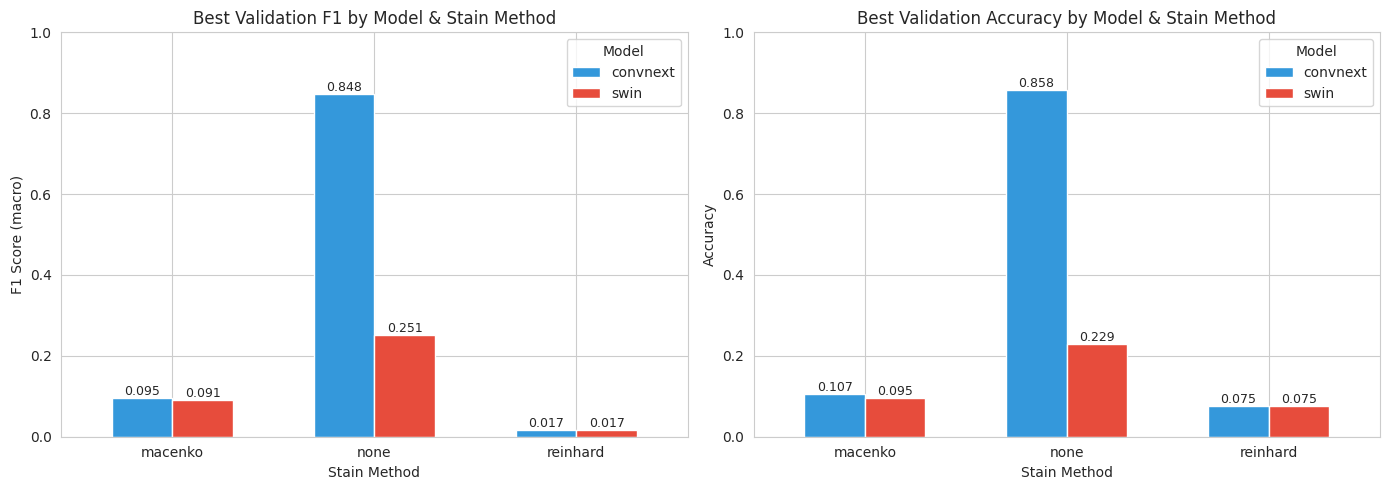

In [12]:
# 4.2 Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 by model and stain method
pivot_f1 = df_results.pivot(index="Stain Method", columns="Model", values="Best Val F1")
pivot_f1.plot(kind="bar", ax=axes[0], color=["#3498db", "#e74c3c"], width=0.6)
axes[0].set_title("Best Validation F1 by Model & Stain Method")
axes[0].set_ylabel("F1 Score (macro)")
axes[0].set_ylim(0, 1)
axes[0].legend(title="Model")
axes[0].tick_params(axis="x", rotation=0)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", fontsize=9)

# Accuracy comparison
pivot_acc = df_results.pivot(index="Stain Method", columns="Model", values="Best Val Acc")
pivot_acc.plot(kind="bar", ax=axes[1], color=["#3498db", "#e74c3c"], width=0.6)
axes[1].set_title("Best Validation Accuracy by Model & Stain Method")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend(title="Model")
axes[1].tick_params(axis="x", rotation=0)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.3f", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "ablation_study_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# 4.3 Analyze effects

# Model effect (averaging across stain methods)
print("MODEL EFFECT (averaged across stain methods):")
for model in ["convnext", "swin"]:
    mask = df_results["Model"] == model
    avg_f1 = df_results[mask]["Best Val F1"].mean()
    avg_acc = df_results[mask]["Best Val Acc"].mean()
    print(f"  {model:<12s} Avg F1: {avg_f1:.4f}  Avg Acc: {avg_acc:.4f}")

# Stain effect (averaging across models)
print("\nSTAIN NORMALIZATION EFFECT (averaged across models):")
for stain in STAIN_METHODS:
    mask = df_results["Stain Method"] == stain
    avg_f1 = df_results[mask]["Best Val F1"].mean()
    avg_acc = df_results[mask]["Best Val Acc"].mean()
    print(f"  {stain:<12s} Avg F1: {avg_f1:.4f}  Avg Acc: {avg_acc:.4f}")

# Best overall
best_row = df_results.iloc[0]
print(f"\nBEST COMBINATION: {best_row['Model']} + {best_row['Stain Method']}")
print(f"  F1: {best_row['Best Val F1']:.4f}  Acc: {best_row['Best Val Acc']:.4f}  (epoch {int(best_row['Best Epoch'])})")

MODEL EFFECT (averaged across stain methods):
  convnext     Avg F1: 0.3203  Avg Acc: 0.3465
  swin         Avg F1: 0.1198  Avg Acc: 0.1331

STAIN NORMALIZATION EFFECT (averaged across models):
  none         Avg F1: 0.5494  Avg Acc: 0.5435
  macenko      Avg F1: 0.0932  Avg Acc: 0.1008
  reinhard     Avg F1: 0.0175  Avg Acc: 0.0751

BEST COMBINATION: convnext + none
  F1: 0.8480  Acc: 0.8577  (epoch 55)


## Summary

### What we trained:
- **6 models**: 2 architectures (ConvNeXt, Swin) x 3 stain methods (none, macenko, reinhard)
- All with identical hyperparameters for a fair comparison

### Key outputs saved:
- **Model checkpoints**: `weights/{experiment_name}/best_model.pth` - used in notebooks 04 and 05
- **Training histories**: `results/{experiment_name}/training_history.csv` - the learning curves
- **Ablation results**: `results/ablation_study_results.csv` - the summary table

### What happens next:
- **Notebook 04** (Evaluation): Load the best checkpoint for each experiment and evaluate on the held-out **test set** (which the model has never seen)
- **Notebook 05** (Explainability): Generate XAI explanations and evaluate them quantitatively